# Проект модуля 4. Разработка модели предсказания вероятности отмены бронирования для снижения финансовых потерь отельного бизнеса.
## Цель
Разработать ML-модель, предсказывающую вероятность отмены брони для минимизации финансовых потерь сети отелей, возникающих из-за поздней отмены бронирования. Повысить загрузку номеров за счёт овербукинга номеров с высокой вероятностью отмены брони. 

### Постановка задачи в терминах машинного обучения
- Тип задачи машинного обучения: бинарная классификация на основе данных с временной структурой.
- Целевая переменная - отмена брони (0/1).
- Модели машинного обучения - случайный лес, градиентный бустинг (реализации в библиотеках XGBoost, CatBoost, LightGBM).
- Необходимо использовать кросс-валидацию данных на основе временных рядов для оценки качества моделей. Количество фолдов - 3.
- Основная метрика - Incremental Revenue. Вспомогательные бизнес-метрики: Динамика доли отмен бронирования, Динамика загрузки отеля; технические метрики: F1, Precision, Recall, Accuracy, .
- Требования к значениям метрик:
    - Доля отмен после внедрения модели — 10%.
    - Загрузка отеля не должна уменьшиться больше чем на 8% после внедрения модели.
    - Относительный IR должен составить не менее 50%.
- Для подбора оптимального набора гиперпараметров следует использовать байесовскую оптимизацию.
- Вероятности принадлежности к классам, возвращаемые моделью, должны быть откалиброваны на отдельной калибровочной выборке.
- Необходимо обеспечить воспроизводимость результатов при помощи указания фиксированного значения `random_state`.
### Задачи:
1. Загрузка таблиц датасета.
2. Исследовательский анализ данных.
2. Объединение таблиц в датасет с единым пространством признаков.
3. Выделение обучающей, калибровочной и тестовой выборок.
5. Предобработка данных для машинного обучения, добавление новых признаков.
6. Обучение базовых моделей случайного леса и градиентного бустинга (разные реализации).
7. Оптимизация моделей путём подбора гиперпараметров.
8. Калибровка лучшей модели и максимизация Incremental Revenue за счёт изменения порога положительного класса.
10. Оценка важности признаков.
11. Расчёт экономической эффективности модели.
11. Формулировка выводов и рекомендаций по дальнейшему усовершенствованию модели.

### Описание данных
#### **Таблица 1: данные об истории бронирования**

Данные в таблице `hotel_bookings` содержат информацию о бронированиях номеров в гостинице. Каждая строка — это отдельная бронь, а столбцы хранят параметры бронирования. 

| **Признак**               | **Описание**                                                                                                                                                                                                                                                                                         |
| ------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| booking_id                | Уникальный номер брони. С помощью него можно идентифицировать каждое бронирование в системе. Пример номера брони: `INN000001310`.                                                                                                                                                                    |
| booking_date              | Дата оформления брони: например, `18.06.2018`.                                                                                                                                                                                                                                                       |
| sales_channel             | Способ оформления брони:  <br>• `офлайн_бронирование` — бронирование через телефон, ресепшен и другими способами без использования интернета.  <br>• `онлайн_бронирование` — бронирование через сайт или приложение.  <br>• `корпоративное_бронирование` — бронирование от компании или организации. |
| adult_count               | Количество взрослых гостей, которые планируют заселиться в отель. Например, `2` означает, что в рамках брони в отель планируют заехать как минимум двое взрослых, не считая детей.                                                                                                                   |
| child_count               | Количество детей, которые заселятся в отель в рамках брони. Например, `0` означает, что детей среди ожидаемых гостей нет.                                                                                                                                                                            |
| returning_customer        | Отметка о том, что клиенты уже бронировали номера в сети отелей. `1` — бронь уже была, `0` — новый клиент.                                                                                                                                                                                           |
| previous_cancellations    | Количество отменённых бронирований у клиента в прошлом. Например, `0` означает, что клиент ни разу не отменял бронирование, а `2` — что он два раза отменял бронь.                                                                                                                                   |
| previous_no_shows         | Сколько раз клиент бронировал номер и по итогу заселялся. `1` означает, что клиент один раз действительно заехал по своей брони, `0` — пока подтверждений брони не было.                                                                                                                             |
| booking_value             | Итоговая стоимость бронирования в рублях.                                                                                                                                                                                                                                                            |
| days_until_checkin        | Количество дней с момента брони до даты заселения. Например, `204` означает, что между бронью и заездом должно было пройти 204 дня.                                                                                                                                                                  |
| weekend_nights            | Количество ночей в периоде проживания, которые приходятся на выходные дни — субботу и воскресенье. Например, `4` означает, что гости будут проживать четыре ночи в выходные дни.                                                                                                                     |
| weekday_nights            | Количество ночей в периоде проживания, которые приходятся на будние дни: с понедельника по пятницу. Например, `2` означает, что гости будут проживать две ночи в будние дни.                                                                                                                         |
| meal_plan                 | Выбранный гостями тип питания. Примеры значений: `тип_питания_1`, `тип_питания_2`.                                                                                                                                                                                                                   |
| parking_included          | Информация о бронировании парковочного места. Например, `0` означает, что парковка не бронировалась.                                                                                                                                                                                                 |
| room_type                 | Категория номера или номеров в брони. Примеры значений: `тип_1`, `тип_4`.                                                                                                                                                                                                                            |
| customer_special_requests | Количество комментариев и пожеланий клиента: например, просьб о дополнительной кровати, раннем заезде и так далее.                                                                                                                                                                                   |
| booking_status            | Целевая переменная, обозначает текущий статус бронирования:  <br>• `отказ_брони` — бронирование было отменено.  <br>• `нет_отказа` — бронирование активно, не отменено.                                                                                                                              |

#### **Таблица 2: данные по истории отзывов о проживании**

Таблица `hotel_reviews` содержит информацию об отзывах гостей, которые заселялись в отель. 

|**Признак**|**Описание**|
|---|---|
|customer_id|Уникальный идентификатор клиента, например, `C0003`. Используется, чтобы связать отзыв и его автора, конкретного гостя.|
|booking_id|Идентификатор брони, по которой оставлен отзыв. Например, `INN000201614` — это номер бронирования, который связывает отзыв с конкретной поездкой.|
|review_date|Дата, когда клиент оставил отзыв: например, `2018-11-21`. Показывает, когда была получена обратная связь.|
|stay_rating|Оценка, которую клиент поставил проживанию. `1` — низший балл, `5` — высший балл.|
|review_text|Развёрнутый комментарий клиента о проживании. В этом поле содержится качественная обратная связь: что понравилось, а что нет. Пример отзыва: «Неплохо. Приветливый персонал на ресепшн, но завтрак однообразный. Питание в ресторане понравилось».|


## 1. Подготовка среды и загрузка данных
### 1.1. Установка библиотек

In [1]:
%pip install -q dotenv
%pip install -q -U numpy==1.26.4 scipy numba matplotlib
%pip install -q scikit-learn==1.6.1
%pip install -q greenlet==3.0.3
%pip install -q pandas==2.2.3
%pip install -q -U sqlalchemy
%pip install -q -U psycopg2-binary
%pip install -q -U seaborn
%pip install -q -U jinja2
%pip install -q -U phik
%pip install -q -U optuna
%pip install -q -U joblib
%pip install -q -U xgboost
%pip install -q -U lightgbm
%pip install -q -U catboost
%pip install -q -U shap
%pip install -q -U nltk

# Сохраним версии библиотек в requirements.txt
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


...

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


### 1.2. Импорт необходимых библиотек

In [2]:
# Системные библиотеки
import os
from dotenv import load_dotenv
import math
import time

# Библиотека для доступа к СУБД
from sqlalchemy import create_engine

# Библиотеки для вычислений и работы с датасетами
import pandas as pd
import numpy as np
import phik

# Библиотеки для обработки текста
import re
import nltk
from nltk.corpus import stopwords

# Библиотеки машинного обучения
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, accuracy_score, precision_score, roc_auc_score, \
    recall_score, brier_score_loss, precision_recall_curve, confusion_matrix, make_scorer
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.inspection import permutation_importance

from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Подбор гиперпараметров
import optuna

# Оценка важности признаков
import shap

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Сериализация пайплайна
import joblib

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1.3. Определение констант

In [51]:
# Константа для воспроизводимости
RANDOM_SEED = 42

# Параметры целевой переменной
TARGET = 'booking_status'
POSITIVE_CLASS_MARKER = 'отказ_брони'

# Количество TF-IDF токенов
MAX_TEXT_FEATURES = 100

# Константы для бизнес-метрик
AVG_REV = 64500
COST_FP = 7000
LOST_REV = 64500
PER_REBOOKING = 45000

pd.options.display.float_format = '{:.4f}'.format

### 1.4. Загрузка данных из СУБД

In [4]:
load_dotenv("hotels.env")

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv("DB_USER"),
    os.getenv("DB_PASSWORD"),
    os.getenv("DB_HOST"),
    os.getenv("DB_PORT"),
    os.getenv("DB_NAME")
)

In [5]:
# Создание пула соединений
engine = create_engine(connection_string) 

hotel_bookings_sql = '''
SELECT *
FROM hotel_bookings
'''

hotel_reviews_sql = '''
SELECT *
FROM hotel_reviews
'''

display(HTML("<h2>Таблица hotel_bookings</h2>"))
df_hotel_bookings = pd.read_sql_query(hotel_bookings_sql, con=engine, parse_dates=['booking_date'])
df_hotel_bookings.info()
display(df_hotel_bookings.head())

display(HTML("<h2>Таблица hotel_reviews</h2>"))
df_hotel_reviews = pd.read_sql_query(hotel_reviews_sql, con=engine, parse_dates=['review_date'])
df_hotel_reviews.info()
display(df_hotel_reviews.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35341 entries, 0 to 35340
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id                 35341 non-null  object        
 1   booking_date               35341 non-null  datetime64[ns]
 2   sales_channel              35341 non-null  object        
 3   adult_count                35341 non-null  int64         
 4   child_count                35341 non-null  int64         
 5   returning_customer         35341 non-null  bool          
 6   previous_cancellations     35341 non-null  int64         
 7   previous_no_shows          35341 non-null  int64         
 8   booking_status             35341 non-null  object        
 9   booking_value              35341 non-null  float64       
 10  days_until_checkin         35341 non-null  int64         
 11  weekday_nights             35341 non-null  int64         
 12  week

,booking_id,booking_date,sales_channel,adult_count,child_count,returning_customer,previous_cancellations,previous_no_shows,booking_status,booking_value,days_until_checkin,weekday_nights,weekend_nights,meal_plan,parking_included,room_type,customer_special_requests
0,INN00000,2020-07-08,корпоративное_бронирование,300,0,False,0,0,нет_отказа,6700.0,21,1,0,тип_питания_2,False,тип_1,0
1,INN00001,2021-09-19,корпоративное_бронирование,3,0,True,0,1,нет_отказа,62300.0,15,5,2,тип_питания_2,False,тип_1,1
2,INN00002,2022-11-19,корпоративное_бронирование,3,0,True,0,2,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,0
3,INN00003,2017-02-11,онлайн_бронирование,2,0,False,0,0,нет_отказа,53600.0,150,6,2,тип_питания_1,False,тип_1,0
4,INN00004,2019-03-06,корпоративное_бронирование,1,0,True,1,1,нет_отказа,46900.0,96,5,2,тип_питания_1,False,тип_1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25177 entries, 0 to 25176
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   customer_id  25177 non-null  object        
 1   booking_id   25177 non-null  object        
 2   review_date  25177 non-null  datetime64[ns]
 3   stay_rating  25177 non-null  int64         
 4   review_text  25177 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(3)
memory usage: 983.6+ KB


,customer_id,booking_id,review_date,stay_rating,review_text
0,C0001,INN00000,2020-08-21,3,"Неплохо. тихо и спокойно, но отсутствие фена в..."
1,C0001,INN00001,2021-10-15,3,"Неплохо. красивое оформление территории, но не..."
2,C0001,INN00002,2023-03-08,4,Отличный отель! удобные парковочные места. зде...
3,C0002,INN00003,2017-08-13,3,"Неплохо. тёплый приём, но неисправная сантехни..."
4,C0003,INN00004,2019-07-12,4,Отличный отель! качественная косметика в ванно...


- Пропусков в данных нет, типы данных и содержимое полей соответствуют описанию.

- Проверим таблицы на наличие дубликатов:

In [6]:
print(f"Количество дубликатов в df_hotel_bookings: {df_hotel_bookings.duplicated().sum()}")
print(f"Количество дубликатов в df_hotel_reviews: {df_hotel_reviews.duplicated().sum()}")

df_hotel_bookings = df_hotel_bookings.drop_duplicates()
df_hotel_reviews = df_hotel_reviews.drop_duplicates()

Количество дубликатов в df_hotel_bookings: 4608
Количество дубликатов в df_hotel_reviews: 0


- Полные дубликаты были найдены в таблице `hotel_bookings` в количестве 4608 строк и удалены из неё.
- Проверим наличие неявных дубликатов в категориальных признаках:

In [7]:
for col in df_hotel_bookings.select_dtypes(include='object').columns:
    if col == 'booking_id':
        continue
    print(f"{col}: {df_hotel_bookings[col].nunique()} уникальных значений")
    print(df_hotel_bookings[col].unique())
    display(HTML("<hr>"))

sales_channel: 3 уникальных значений
['корпоративное_бронирование' 'онлайн_бронирование' 'офлайн_бронирование']


booking_status: 2 уникальных значений
['нет_отказа' 'отказ_брони']


meal_plan: 5 уникальных значений
['тип_питания_2' 'тип_питания_1' 'не выбран' 'не выбрант' 'тип_питания_3']


room_type: 7 уникальных значений
['тип_1' 'тип_4' 'тип_6' 'тип_2' 'тип_5' 'тип_7' 'тип_3']


- В столбце `meal_plan` присутствуют неявные дубликаты, вероятно, из-за ошибки ввода данных. Исправим эту ошибку:

In [8]:
df_hotel_bookings['meal_plan'] = df_hotel_bookings['meal_plan'].replace('не выбрант', 'не выбран')
print(df_hotel_bookings['meal_plan'].unique())

['тип_питания_2' 'тип_питания_1' 'не выбран' 'тип_питания_3']


- В загруженных таблицах `hotel_bookings`, `hotel_reviews` было 35341 и 25177 строк соответственно.
- В таблице `hotel_bookings` были найдены явные и неявные дубликаты. Явные дубликаты были удалены, неявные исправлены.
- Количество строк после исправлений:

In [9]:
print(f"Количество строк в df_hotel_bookings: {df_hotel_bookings.shape[0]}")
print(f"Количество строк в df_hotel_reviews: {df_hotel_reviews.shape[0]}")

Количество строк в df_hotel_bookings: 30733
Количество строк в df_hotel_reviews: 25177


## 2. Исследовательский анализ данных
- Функции для построения графиов и диаграмм:

In [10]:
# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, xlabel, ylabel, hue=None, stat='count', figsize=(12, 6), bins='auto', kde=True, **kwargs):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel(xlabel)  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat,
                **kwargs)

    # ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)
    
    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

# Функция для построения гистограммы
def draw_histogram(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                **kwargs)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы в сетке
def draw_histogram_in_grid(data,
                        field,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    sns.histplot(data=data,
                x=field,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_histogram_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = math.ceil(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_histogram_in_grid(
                value['data'],
                value['x'],
                value['title'] if 'title' in value else value['x'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения столбчатой диаграммы в сетке
def draw_barplot_grid(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 **kwargs):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot,
        **kwargs)
    
    # kwargs['ax'].legend(bbox_to_anchor=(1, 1))
    
    if mean != None:
        if vertical:
            kwargs['ax'].axhline(mean, color='red', linestyle='--')
        else:
            kwargs['ax'].axvline(mean, color='red', linestyle='--')   

def show_barplot_grid(features_desc, title, n_columns=2, **kwargs):
    n_lines = math.ceil(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(features_desc):
        draw_barplot_grid(
                value['data'],
                value['title'], 
                value['xlabel'] if 'xlabel' in value else "Значение", 
                value['ylabel'] if 'ylabel' in value else "Количество", 
                value['rot'] if 'rot' in value else 0, 
                value['vertical'] if 'vertical' in value else True,
                value.get('mean'),
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_in_grid(data, 
                     x, 
                     y, 
                     title,
                     xlabel, 
                     ylabel,
                     **kwargs):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    **kwargs)
    kwargs['ax'].set_title(title)
    kwargs['ax'].set_xlabel(xlabel)
    kwargs['ax'].set_ylabel(ylabel)

def show_scatterplot_grid(df, features_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(features_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, (key, value) in enumerate(features_desc.items()):
        draw_scatterplot_in_grid(
                df,
                key[0],
                key[1],
                value['title'] if 'title' in value else "/".join(key), 
                value['xlabel'] if 'xlabel' in value else key[0], 
                value['ylabel'] if 'ylabel' in value else key[1], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(14,14), font_scale=0.6):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.set_theme(font_scale=font_scale)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.show()

def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None,
                 figsize=None):
    series.plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=figsize if figsize != None else (8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

def draw_qqplot_in_grid(data1, 
                        data2,
                        title,
                        xlabel, 
                        ylabel,
                        **kwargs):
    q = np.linspace(0, 1, 100)
    data1_q = np.quantile(data1.dropna(), q)
    data2_q = np.quantile(data2.dropna(), q)

    ax = kwargs.pop('ax')
    ax.scatter(data1_q, data2_q, **kwargs)

    mn = min(data1.min(), data2.min())
    mx = max(data1.max(), data2.max())

    ax.plot([mn, mx], [mn, mx], linestyle='--', color='red')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def show_qqplot_grid(data_desc, title, n_columns=2, **kwargs):
    n_lines = round(len(data_desc) / n_columns)
    _, axes = plt.subplots(n_lines, n_columns, 
                         figsize=(12, n_lines * 4))
    axes = axes.flatten()
    for i, value in enumerate(data_desc):
        draw_qqplot_in_grid(
                value['data1'],
                value['data2'],
                value['title'], 
                value['xlabel'], 
                value['ylabel'], 
                ax=axes[i],
                **kwargs
                )

    plt.suptitle(title, fontsize=16, y=1)
    plt.tight_layout()
    plt.show()    

### 2.1. Распределение целевой переменной

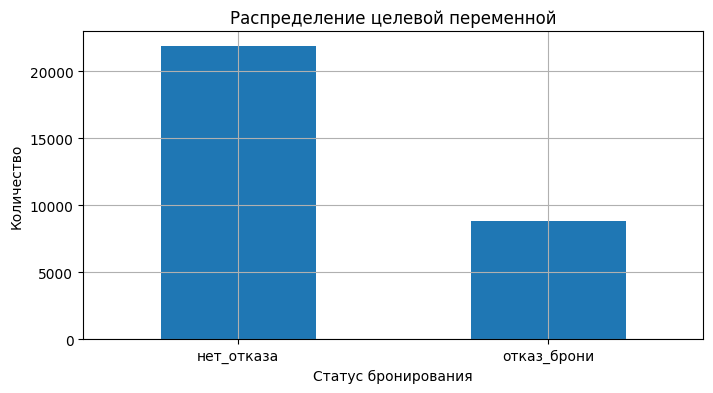

In [11]:
draw_barplot(df_hotel_bookings[TARGET].value_counts(),
             title='Распределение целевой переменной',mean=None,
             xlabel='Статус бронирования', ylabel='Количество', rot=0, vertical=True)

- Классы несбалансированы, положительный класс в 2.5 раза меньше отрицательного. Исправление дисбаланса не требуется.

### 2.2. Статистика и кардинальность признаков

- Определим кардинальность признаков и статистики по числовым признакам:

In [12]:
display(HTML("<h3>Статистики по числовым признакам<h3>"))
display(df_hotel_bookings.select_dtypes(include='number').describe())
display(HTML("<h3>Кардинальность признаков<h3>"))
display(df_hotel_bookings.nunique())
print(f"Даты с {df_hotel_bookings['booking_date'].min()} по {df_hotel_bookings['booking_date'].max()}")

latest_arrival_date = max(df_hotel_bookings['booking_date'] + 
                          pd.to_timedelta(df_hotel_bookings['days_until_checkin'], unit='D'))
print(f"Самая поздняя дата заселения : {latest_arrival_date}")

,adult_count,child_count,previous_cancellations,previous_no_shows,booking_value,days_until_checkin,weekday_nights,weekend_nights,customer_special_requests
count,30733.000000,30733.000000,30733.000000,30733.00000,30733.000000,30733.000000,30733.000000,30733.000000,30733.000000
mean,14.082387,0.356685,0.357303,0.83900,61679.168347,100.598770,6.536687,1.954772,0.620603
std,48.832586,0.584576,0.629688,0.93191,42737.289170,71.933406,3.336198,1.476409,0.784428
min,1.000000,0.000000,0.000000,0.00000,0.000000,2.000000,1.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.00000,33500.000000,45.000000,5.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,1.00000,60300.000000,90.000000,6.000000,2.000000,0.000000
75%,3.000000,1.000000,1.000000,1.00000,80400.000000,144.000000,9.000000,2.000000,1.000000
max,300.000000,2.000000,5.000000,5.00000,417221.200000,300.000000,15.000000,6.000000,5.000000


booking_id                   30733
booking_date                  2445
sales_channel                    3
adult_count                      6
child_count                      3
returning_customer               2
previous_cancellations           6
previous_no_shows                6
booking_status                   2
booking_value                 1766
days_until_checkin              79
weekday_nights                  14
weekend_nights                   4
meal_plan                        4
parking_included                 2
room_type                        7
customer_special_requests        6
dtype: int64

Даты с 2017-01-01 00:00:00 по 2025-10-22 00:00:00
Самая поздняя дата заселения : 2026-02-06 00:00:00


### 2.3. Распределение признаков совместно с целевой переменной
- Для признаков с большим количеством значений построим гистограммы

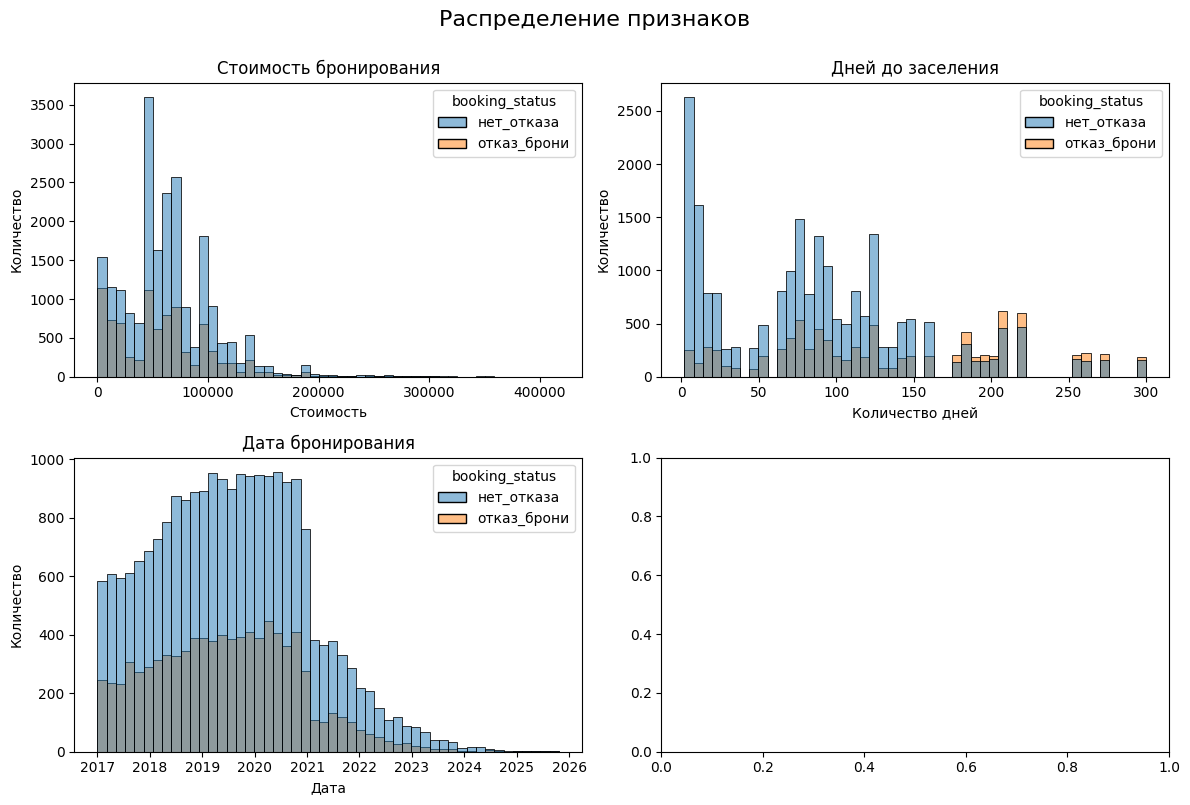

In [13]:
hist_num_desc = [
    {'data': df_hotel_bookings, 'x': 'booking_value', 'title': "Стоимость бронирования",
     'xlabel': "Стоимость", 'ylabel': "Количество"},
    {'data': df_hotel_bookings, 'x': 'days_until_checkin', 'title': "Дней до заселения",
     'xlabel': "Количество дней", 'ylabel': "Количество"},
    {'data': df_hotel_bookings, 'x': 'booking_date', 'title': "Дата бронирования",
     'xlabel': "Дата", 'ylabel': "Количество"}
]

show_histogram_grid(hist_num_desc, hue=TARGET, 
                    title="Распределение признаков", bins=50, n_columns=2)


- Для признаков с небольшой кардинальностью и категориальных построим столбчатые диаграммы:

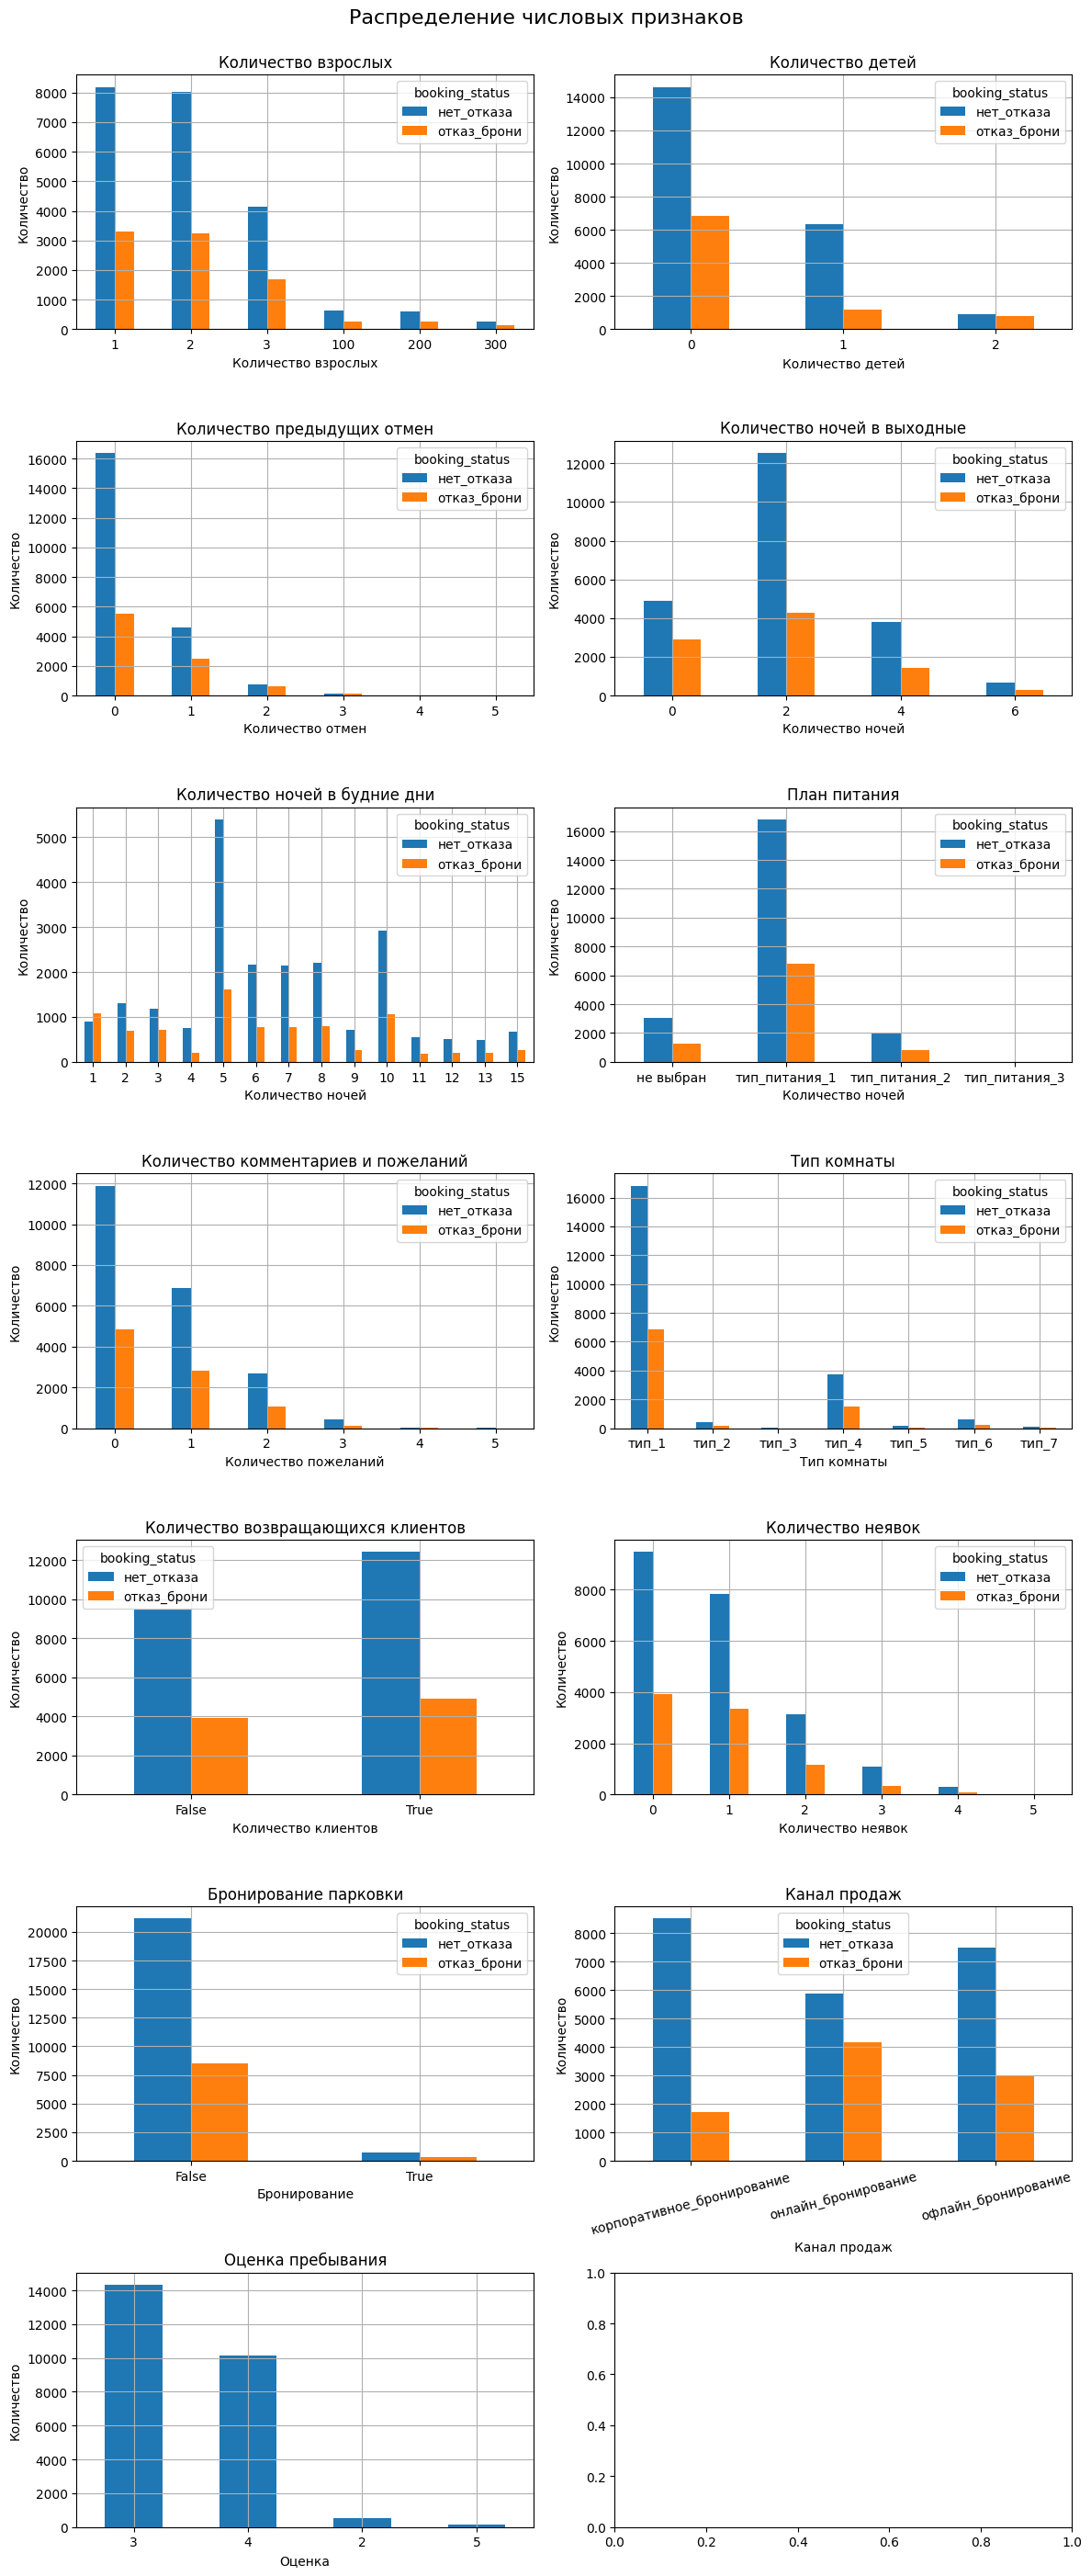

In [14]:
barplot_num_desc = [
    {'data': (df_hotel_bookings.groupby('adult_count')[TARGET]
              .value_counts()
              .unstack()
              .sort_values(by='adult_count', ascending=True)), 
     'title': "Количество взрослых", 'xlabel': "Количество взрослых", 'ylabel': "Количество"},
    {'data': (df_hotel_bookings
              .groupby('child_count')[TARGET]
              .value_counts()
              .unstack()
              .sort_values(by='child_count', ascending=True)), 
     'title': "Количество детей", 'xlabel': "Количество детей", 'ylabel': "Количество"},
    {'data': (df_hotel_bookings
              .groupby('previous_cancellations')[TARGET]
              .value_counts()
              .unstack()
              .sort_values(by='previous_cancellations', ascending=True)), 
     'title': "Количество предыдущих отмен", 'xlabel': "Количество отмен", 'ylabel': "Количество"},
    {'data': (df_hotel_bookings
              .groupby('weekend_nights')[TARGET]
              .value_counts()
              .unstack()
              .sort_values(by='weekend_nights', ascending=True)), 
     'title': "Количество ночей в выходные", 'xlabel': "Количество ночей", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('weekday_nights')[TARGET].value_counts().unstack(), 
     'title': "Количество ночей в будние дни", 'xlabel': "Количество ночей", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('meal_plan')[TARGET].value_counts().unstack(), 
     'title': "План питания", 'xlabel': "Количество ночей", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('customer_special_requests')[TARGET].value_counts().unstack(), 
     'title': "Количество комментариев и пожеланий", 'xlabel': "Количество пожеланий", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('room_type')[TARGET].value_counts().unstack(), 
     'title': "Тип комнаты", 'xlabel': "Тип комнаты", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('returning_customer')[TARGET].value_counts().unstack(), 
     'title': "Количество возвращающихся клиентов", 'xlabel': "Количество клиентов", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('previous_no_shows')[TARGET].value_counts().unstack(), 
     'title': "Количество неявок", 'xlabel': "Количество неявок", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('parking_included')[TARGET].value_counts().unstack(), 
     'title': "Бронирование парковки", 'xlabel': "Бронирование", 'ylabel': "Количество"},
    {'data': df_hotel_bookings.groupby('sales_channel')[TARGET].value_counts().unstack(), 
     'title': "Канал продаж", 'xlabel': "Канал продаж", 'ylabel': "Количество", 'rot': 15},
    {'data': df_hotel_reviews['stay_rating'].value_counts(), 
     'title': "Оценка пребывания", 'xlabel': "Оценка", 'ylabel': "Количество"}
]

show_barplot_grid(barplot_num_desc, "Распределение числовых признаков")

- Необходимо добавить признаки месяца и дня недели заселения, чтобы определить влияние на целевую переменную сезонных и недельных колебаний, которые свойственны гостиничному бизнесу.

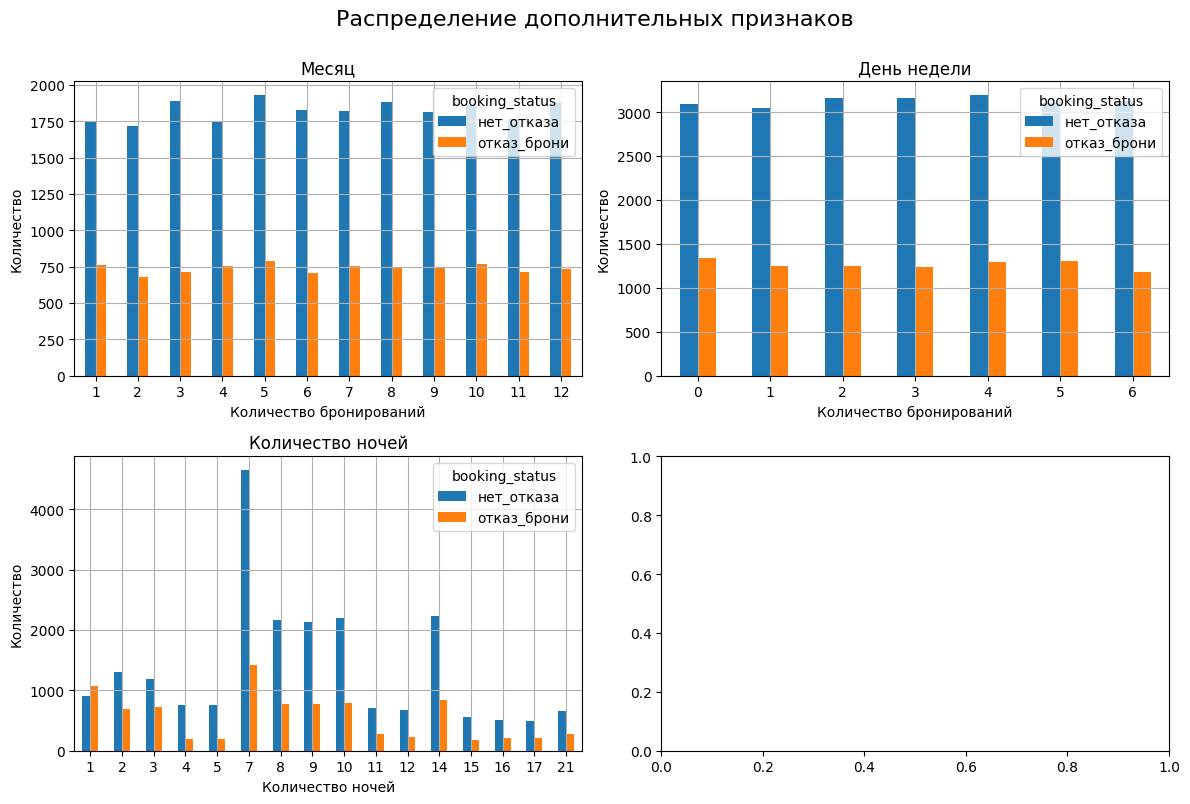

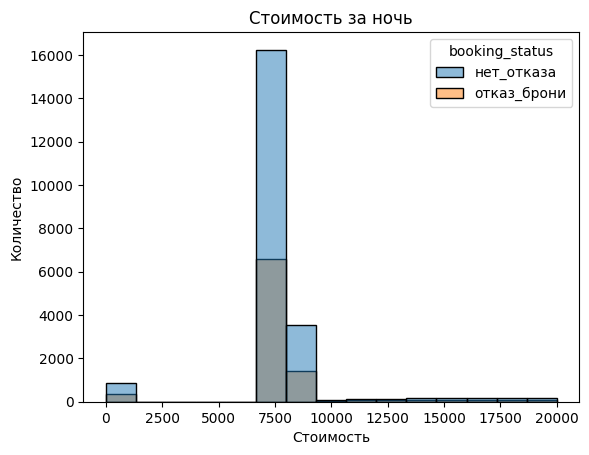

In [15]:
def add_features(df):
    df['arrival_month'] = (df['booking_date'] 
        + pd.to_timedelta(df['days_until_checkin'], unit='D')).dt.month
    df['arrival_dow'] = (df['booking_date'] 
        + pd.to_timedelta(df['days_until_checkin'], unit='D')).dt.dayofweek
    df['total_nights'] = df['weekday_nights'] + df['weekend_nights']
    df['cost_per_night'] = df['booking_value'] / df['total_nights']

    # Категориальные признаки
    df['meal_plan'] = df['meal_plan'].astype('category')
    df['room_type'] = df['room_type'].astype('category')
    df['sales_channel'] = df['sales_channel'].astype('category')

    return df

df_hotel_bookings_ext = add_features(df_hotel_bookings.copy())

barplot_date_desc = [
    {'data': df_hotel_bookings_ext.groupby('arrival_month')[TARGET].value_counts().unstack(), 
     'title': "Месяц", 'xlabel': "Количество бронирований", 'ylabel': "Количество"},
    {'data': df_hotel_bookings_ext.groupby('arrival_dow')[TARGET].value_counts().unstack(), 
     'title': "День недели", 'xlabel': "Количество бронирований", 'ylabel': "Количество"},
    {'data': df_hotel_bookings_ext.groupby('total_nights')[TARGET].value_counts().unstack(), 
     'title': "Количество ночей", 'xlabel': "Количество ночей", 'ylabel': "Количество"}
]

show_barplot_grid(barplot_date_desc, "Распределение дополнительных признаков")
draw_histogram(df_hotel_bookings_ext, 'cost_per_night', "Стоимость за ночь", "Стоимость", "Количество", 
               hue=TARGET, bins=15)

- Данные о бронировании представлены за период с 01.01.2017 по 22.10.2025. Пик приходится на 2020 год, начиная с 2021 года количество записей о бронировании начинает резко убывать. Это надо учитывать при разделении датасета на выборки.
- Самая поздняя дата заселения - 06.02.2026, следовательно данные полны, и значение целевой переменной для всех данных определено.
- При увеличении количества дней от бронирования до заселения более 170 вероятность отмены резко становится выше 50%.
- Выбросы в количестве взрослых постояльцев и стоимости бронирования (до 400000 р.) не являются аномалиями, так как относятся к корпоративному сегменту.
- Продолжительность большей часть бронирований составляет 7-10 дней или две недели.
- Среди признаков, указывающих на высокую вероятность отмены брони, можно отметить наличие двух детей, время до заселения более 150 дней, наличие предыдущих отмен, бронирование на одну ночь в будние дни, онлайн-бронирование.

### 2.4. Исследование корреляций признаков
- Построим тепловую карту корреляций признаков:

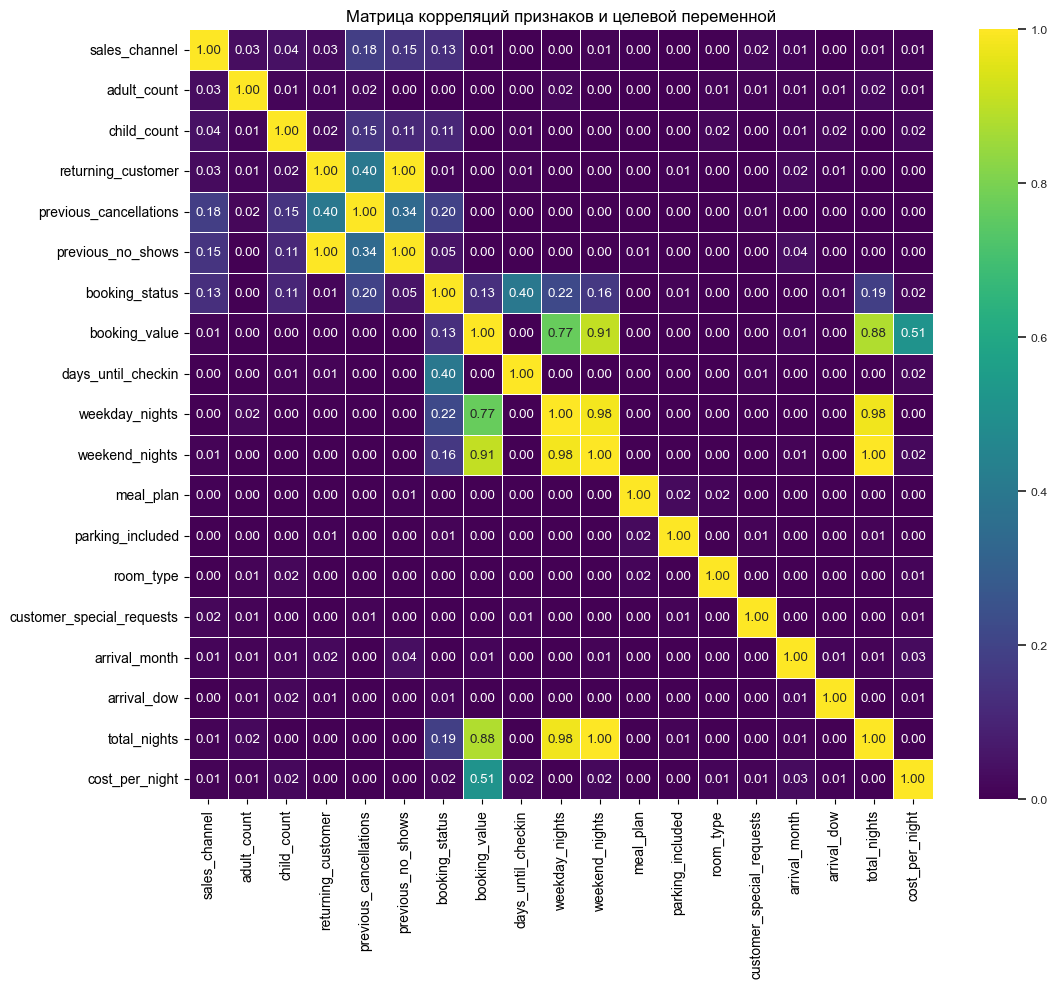

In [16]:
corr_columns = df_hotel_bookings_ext.columns.tolist()
corr_columns.remove('booking_id')
corr_columns.remove('booking_date')
phik_matrix = phik.phik_matrix(df_hotel_bookings_ext[corr_columns], 
                               interval_cols=['booking_value', 'days_until_checkin', 'total_nights', 'cost_per_night'])
draw_heatmap(phik_matrix, title="Матрица корреляций признаков и целевой переменной", figsize=(12, 10), font_scale=0.8)

### 2.5. Выводы
- Данные о бронировании представлены за период с 01.01.2017 по 22.10.2025. Пик приходится на 2020 год, начиная с 2021 года количество записей о бронировании начинает резко убывать. Это надо учитывать при разделении датасета на выборки.
- При увеличении количества дней от бронирования до заселения более 170 вероятность отмены резко становится выше 50%.
- Выбросы в количестве взрослых постояльцев и стоимости бронирования (до 400000 р.) не являются аномалиями, так как относятся к корпоративному сегменту.
- Колебание количества ночей в будние дни, указывает на то, что продолжительность большей часть бронирований составляет одну или две недели.
- Среди признаков, указывающих на высокую вероятность отмены брони, можно отметить наличие двух детей, время до заселения более 150 дней, наличие предыдущих отмен, бронирование на одну ночь в будние дни, онлайн-бронирование.
- Матрица корреляций дополняет предыдущие выводы. Наиболее сильные корреляции целевой переменной - с количеством дней до заселения, количеством ночей в будние и выходные дни, предыдущими отменами, каналом продаж, количеством детей.

## 3. Предобработка данных
### 3.1. Объединение таблиц

In [17]:
def join_tables(df_bookings, df_reviews):
    # Добавим в таблицу бронирований customer_id
    df_bookings_ext = pd.merge(df_bookings, df_reviews[['booking_id', 'customer_id']], 
                                 on='booking_id', how='left')

    # Объединим таблицы бронирований и отзывов по customer_id и предыдущей дате отзыва
    df = pd.merge_asof(df_bookings_ext.sort_values('booking_date'),
                       df_reviews.sort_values('review_date'),
                       left_on='booking_date',
                       right_on='review_date',
                       by='customer_id',
                       direction='backward')
    return df

df = join_tables(df_hotel_bookings, df_hotel_reviews).sort_values('booking_date')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34027 entries, 0 to 34026
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   booking_id_x               34027 non-null  object        
 1   booking_date               34027 non-null  datetime64[ns]
 2   sales_channel              34027 non-null  object        
 3   adult_count                34027 non-null  int64         
 4   child_count                34027 non-null  int64         
 5   returning_customer         34027 non-null  bool          
 6   previous_cancellations     34027 non-null  int64         
 7   previous_no_shows          34027 non-null  int64         
 8   booking_status             34027 non-null  object        
 9   booking_value              34027 non-null  float64       
 10  days_until_checkin         34027 non-null  int64         
 11  weekday_nights             34027 non-null  int64         
 12  weekend_n

- Разделим таблицу на выборки - обучающую, калибровочную и тестовую. Поскольку данные имеют временную структуру, произведём разделение отсортированных по `booking_date` данных без стратификации:

In [18]:
X = df.drop(columns=[TARGET])
y = (df[TARGET] == POSITIVE_CLASS_MARKER).astype('int8')

X_train_cal, X_test, y_train_cal, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
X_train, X_cal, y_train, y_cal = train_test_split(X_train_cal, y_train_cal, test_size=0.25, shuffle=False)

display(pd.DataFrame({"Выборка": ["train", "calibration", "test"],
                      "Размер": [X_train.shape[0], X_cal.shape[0], X_test.shape[0]],
                      "Начальная дата": [X_train['booking_date'].min(), X_cal['booking_date'].min(), X_test['booking_date'].min()],
                      "Конечная дата": [X_train['booking_date'].max(), X_cal['booking_date'].max(), X_test['booking_date'].max()]}))

,Выборка,Размер,Начальная дата,Конечная дата
0,train,20415,2017-01-01,2019-11-29
1,calibration,6806,2019-11-29,2020-09-20
2,test,6806,2020-09-20,2025-10-22


### 3.2. Предобработка для векторизации текстовых комментариев
- **ΝΒ Векторизация комментариев практически бесполезна, так как предыдущие оценки с комментариями в датасете присутствуют только для подтвержденных бронирований, а для отмененных их нет.**
- Функции предобработки текстовых комментариев - приведем слова к нижнему регистру и удалим стоп-слова и знаки препинания:

In [19]:
nltk.download('stopwords')
stop_words = set(stopwords.words('russian'))

# Функция для предобработки текста
def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = text.lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = [word for word in text.split() if word not in stop_words]
    return ' '.join(words)

def preprocess_comments(df):
    df['review_clean'] = df['review_text'].apply(preprocess_text)
    return df

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\astuser\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### 3.3. Пайплайны предобработки
- Для CatBoost нет необходимости использовать TF-IDF, так как `CatBoostClassifier` поддерживает векторизацию текстовых признаков.
- Для прочих библиотек будет использован `TfidfVectorizer` и `OneHotEncoder` для текстовых категориальных признаков. Использование `OneHotEncoder` необходимо, потому что иначе не получится соединить признаки TF-IDF в виде разреженной матрицы с нечисловыми категориальными признаками.

- Соберём пайплайны предобработки с генерацией признаков, векторизацией комментариев и заполнением пропусков в рейтинге заглушкой -1:

In [20]:
num_features = ['booking_value', 'days_until_checkin', 'total_nights', 'cost_per_night',
                'adult_count', 'child_count', 'previous_cancellations', 'previous_no_shows', 
                'weekend_nights', 'weekday_nights', 'customer_special_requests',
                'returning_customer', 'parking_included', 'arrival_month', 'arrival_dow',
                'stay_rating']
cat_features = ['meal_plan', 'room_type', 'sales_channel']
text_features = 'review_clean'

def feature_engineering(df):
    df_new = df.copy()
    df_new = add_features(df_new)
    df_new = preprocess_comments(df_new)
    return df_new[num_features + cat_features + [text_features]]

ohe_tfidf_pp = Pipeline([
        ('feng', FunctionTransformer(feature_engineering, validate=False)),
        ('ct', ColumnTransformer(transformers=[
                    ('text', TfidfVectorizer(max_features=MAX_TEXT_FEATURES), text_features),
                    ('na', SimpleImputer(strategy='constant', fill_value=-1), ['stay_rating']),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_features)],
                    remainder='passthrough'
                ))                
])

- Пайплайн предобработки для CatBoost:

In [21]:
no_pp = Pipeline([
        ('feng', FunctionTransformer(feature_engineering, validate=False)),
        ('ct', ColumnTransformer(transformers=[
                    ('na', SimpleImputer(strategy='constant', fill_value=-1), ['stay_rating'])
                    ],
                    remainder='passthrough',
                    verbose_feature_names_out=False
                ))                
])

no_pp.set_output(transform='pandas')

Pipeline(steps=[('feng',
                 FunctionTransformer(func=<function feature_engineering at 0x000001DB38D660D0>)),
                ('ct',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('na',
                                                  SimpleImputer(fill_value=-1,
                                                                strategy='constant'),
                                                  ['stay_rating'])],
                                   verbose_feature_names_out=False))])

### 3.4. Выводы
- Данные разделены на обучающую, калибровочную и тестовую выборки в соотношении 3:1:1 по количеству записей с учетом временной структуры.
- Созданы пайплайны предобработки:
    - для CatBoost без предобработки текстовых и категориальных признаков;
    - для других моделей - с кодированием категориальных признаков и векторизацией текстового поля комментария.

## 4. Обучение базовых моделей
### 4.1. Описание функций для бизнес-метрик
**Замечание:**
- Так как нам неизвестно количество номеров в отелях и их вместимость, для вычисления динамики загрузки отелей будем оперировать количеством бронирований. Для перевода количества бронирований в количество номеров/ночей необходимо разделить среднее количество гостей по выборке на среднюю вместимость номера и умножить на среднее количество ночей по выборке. Средние значения можно считать константами, зависящими от признаков выборки. Тогда качество модели полностью определяется предсказаниями отмен бронирований.

In [22]:
def cancellation_ratio_before(y):
    # Доля отмен до = Доля фактических отмен
    return (y == 1).mean() * 100

def cancellation_ratio_after(y, y_pred):
    # Доля отмен после = доля непредсказанных отмен (FN)
    return ((y == 1) & (y_pred == 0)).mean() * 100

def revenue_before(y):
    return (y == 0).sum() * AVG_REV - (y == 1).sum() * LOST_REV

def revenue_after(y, y_pred):
    cm = confusion_matrix(y, y_pred)
    return cm[1, 1] * PER_REBOOKING + cm[0, 0] * AVG_REV - cm[0, 1] * COST_FP - cm[1, 0] * LOST_REV

def load_before(y):
    return (y == 0).mean() * 100 # Бронь не отменена

def load_after(y, y_pred):
    # Загрузка после внедрения модели - Правильно предсказанные отмены (ребукинг) + 
    #                                   правильно предсказанные неотмены + 
    #                                   неправильно предсказанные отмены
    return ((y_pred == y) | ((y == 0) & (y_pred == 1))).mean() * 100 # TP + TN + FP

def incremental_revenue(y, y_pred):
    ir_before = revenue_before(y)
    ir_after = revenue_after(y, y_pred)
    return (ir_after - ir_before) / ir_before * 100

def cancellation_dynamic(y, y_pred):
    
    # Доля отмен до = Доля фактических отмен
    c_ratio = cancellation_ratio_before(y)

    # Доля отмен после = доля непредсказанных отмен (FN)
    c_ratio_after = cancellation_ratio_after(y, y_pred)
    return (c_ratio - c_ratio_after) / c_ratio * 100

def load_dynamic(y, y_pred):
    l_before = load_before(y)
    # Загрузка после внедрения модели - Правильно предсказанные отмены (ребукинг) + 
    #                                   правильно предсказанные неотмены + 
    #                                   неправильно предсказанные отмены
    l_after = load_after(y, y_pred)

    return (l_before - l_after) / l_before * 100

def calc_metrics(y, y_pred, prefix=''):
    return pd.Series({prefix + 'accuracy': accuracy_score(y, y_pred),
                    prefix + 'precision': precision_score(y, y_pred),
                    prefix + 'recall': recall_score(y, y_pred),
                    prefix + 'f1': f1_score(y, y_pred),
                    prefix + 'IR': incremental_revenue(y, y_pred),
                    prefix + 'CD': cancellation_dynamic(y, y_pred),
                    prefix + 'LD': load_dynamic(y, y_pred)
                    })

- Описание параметров для проверки модели на кросс-валидации:

In [23]:
# Разделение на фолды
cv = TimeSeriesSplit(n_splits=3, test_size=2000)

# Скореры для бизнес-метрик
ir_scorer = make_scorer(incremental_revenue, greater_is_better=True)
cd_scorer = make_scorer(cancellation_dynamic, greater_is_better=True)
ld_scorer = make_scorer(load_dynamic, greater_is_better=True)

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'IR': ir_scorer,
    'CD': cd_scorer,
    'LD': ld_scorer
}

### 4.2. Обучение базового `DummyClassifier`

In [24]:
dummy_metrics = cross_validate(DummyClassifier(strategy='stratified'), X_train, y_train, 
                               cv=cv, n_jobs=-1, scoring=scoring, error_score='raise')
dummy_metrics_df = pd.DataFrame(dummy_metrics).T
display(dummy_metrics_df)

,0,1,2
fit_time,0.019245,0.012157,0.012157
score_time,0.012157,0.026092,0.027092
test_accuracy,0.622000,0.616500,0.573500
test_precision,0.303309,0.268953,0.231579
test_recall,0.304428,0.291585,0.241316
test_f1,0.303867,0.279812,0.236347
test_roc_auc,0.500705,0.509749,0.507143
test_IR,-15.285535,-20.040900,-28.856717
test_CD,30.442804,29.158513,24.131627
test_LD,-11.316872,-10.006716,-9.084652


### 4.3. Обучение модели `RandomForestClassifier`

In [25]:
rf_pipeline = Pipeline([
    ('pp', clone(ohe_tfidf_pp)),
    ('model', RandomForestClassifier(random_state=RANDOM_SEED))
])

rf_metrics = cross_validate(rf_pipeline, X_train, y_train, cv=cv, n_jobs=-1, 
                            scoring=scoring, error_score='raise')


rf_metrics_df = pd.DataFrame(rf_metrics).T
display(rf_metrics_df)

,0,1,2
fit_time,22.463623,26.843029,32.054670
score_time,0.426812,0.421803,0.372480
test_accuracy,0.796500,0.834000,0.806500
test_precision,0.674419,0.741240,0.706186
test_recall,0.481550,0.538160,0.500914
test_f1,0.561895,0.623583,0.586096
test_roc_auc,0.846791,0.875413,0.876954
test_IR,33.124302,36.854996,37.394117
test_CD,48.154982,53.816047,50.091408
test_LD,-17.901235,-18.468771,-18.857536


### 4.4. Обучение модели `XGBClassifier`

In [26]:
xgb_pipeline = Pipeline([
    ('pp', clone(ohe_tfidf_pp)),
    ('model', XGBClassifier(random_state=RANDOM_SEED))
])

xgb_metrics = cross_validate(xgb_pipeline, X_train, y_train, cv=cv, n_jobs=-1, 
                             scoring=scoring, error_score='raise')

xgb_metrics_df = pd.DataFrame(xgb_metrics).T
display(xgb_metrics_df)

,0,1,2
fit_time,1.506044,1.676172,1.960332
score_time,0.206509,0.206599,0.201637
test_accuracy,0.812500,0.846500,0.819500
test_precision,0.707196,0.762887,0.719340
test_recall,0.525830,0.579256,0.557587
test_f1,0.603175,0.658509,0.628218
test_roc_auc,0.853679,0.886224,0.885848
test_IR,38.540503,40.953694,42.591167
test_CD,52.583026,57.925636,55.758684
test_LD,-19.547325,-19.879113,-20.991053


### 4.5. Обучение модели `CatBoostClassifier`

In [27]:
cb_pipeline = Pipeline([
    ('pp', clone(no_pp)),
    ('model', CatBoostClassifier(random_state=RANDOM_SEED))
])

cb_metrics = cross_validate(cb_pipeline, X_train, y_train, cv=cv, n_jobs=-1, 
                            scoring=scoring, error_score='raise', 
                            params={'model__cat_features': cat_features,
                                        'model__text_features': [text_features],
                                        'model__verbose': False})

cb_metrics_df = pd.DataFrame(cb_metrics).T
display(cb_metrics_df)

,0,1,2
fit_time,130.386367,147.206075,150.383829
score_time,0.125875,0.122504,0.148845
test_accuracy,0.820500,0.844500,0.824000
test_precision,0.760684,0.767380,0.764228
test_recall,0.492620,0.561644,0.515539
test_f1,0.597984,0.648588,0.615721
test_roc_auc,0.869635,0.896412,0.897562
test_IR,39.319082,39.958149,42.196725
test_CD,49.261993,56.164384,51.553931
test_LD,-18.312757,-19.274681,-19.408121


### 4.6. Обучение модели `LGBMClassifier`

In [28]:
lgbm_pipeline = Pipeline([
    ('pp', clone(ohe_tfidf_pp)),
    ('model', LGBMClassifier(random_state=RANDOM_SEED))
])

lgbm_metrics = cross_validate(lgbm_pipeline, X_train, y_train, 
                              cv=cv, n_jobs=-1, scoring=scoring, error_score='raise')

lgbm_metrics_df = pd.DataFrame(lgbm_metrics).T
display(lgbm_metrics_df)

,0,1,2
fit_time,8.659195,8.675642,8.441596
score_time,0.146812,0.151215,0.182450
test_accuracy,0.815000,0.843500,0.820000
test_precision,0.725131,0.767568,0.744125
test_recall,0.511070,0.555773,0.521024
test_f1,0.599567,0.644722,0.612903
test_roc_auc,0.866411,0.895081,0.895200
test_IR,38.631055,39.550736,41.412975
test_CD,51.107011,55.577299,52.102377
test_LD,-18.998628,-19.073203,-19.614591


### 4.7. Сравнение базовых моделей
- Сравним средние значения метрик моделей по фолдам:

In [29]:
base_metrics = pd.DataFrame({
    'DummyClassifier': dummy_metrics_df.mean(axis=1),
    'RandomForestClassifier': rf_metrics_df.mean(axis=1),
    'XGBClassifier': xgb_metrics_df.mean(axis=1),
    'CatBoostClassifier': cb_metrics_df.mean(axis=1),
    'LGBMClassifier': lgbm_metrics_df.mean(axis=1)
})

display(base_metrics)

,DummyClassifier,RandomForestClassifier,XGBClassifier,CatBoostClassifier,LGBMClassifier
fit_time,0.014520,27.120440,1.714183,142.658757,8.592144
score_time,0.021780,0.407032,0.204915,0.132408,0.160159
test_accuracy,0.604000,0.812333,0.826167,0.829667,0.826167
test_precision,0.267947,0.707281,0.729807,0.764097,0.745608
test_recall,0.279110,0.506875,0.554224,0.523268,0.529289
test_f1,0.273342,0.590525,0.629967,0.620764,0.619064
test_roc_auc,0.505866,0.866386,0.875250,0.887870,0.885564
test_IR,-21.394384,35.791138,40.695121,40.491319,39.864922
test_CD,27.910981,50.687479,55.422449,52.326769,52.928896
test_LD,-10.136080,-18.409181,-20.139164,-18.998520,-19.228807


- Все модели показывают лучшие результаты по всем метрикам, кроме динамики загрузки, чем базовый `DummyClassifier`.
- Из моделей градиентного бустинга лучший результат по метрике IR - у `XGBClassifier`. Баланс precision/recall у этой модель немного смещён в сторону полноты (recall); 
- У модели `CatBoostRegressor` второй результат по IR, она находит меньше отмен, но более точна (баланс смещён в сторону precision).

## 5. Оптимизация моделей
- Для ранней остановки будем использовать метрику Log loss, для оценки гиперпараметров - Incremental Revenue.
### 5.1. Подбор гиперпараметров модели `RandomForestClassifier`

In [30]:
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'max_features': trial.suggest_float('max_features', 0.5, 1),
        'random_state': RANDOM_SEED
    }

    scores = []

    for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        rf_pipeline = Pipeline([
            ('pp', clone(ohe_tfidf_pp)),
            ('model', RandomForestClassifier(**params))
        ])
        rf_pipeline.fit(X_train_fold, y_train_fold)
        scores.append(calc_metrics(y_val_fold, rf_pipeline.predict(X_val_fold))['IR'])

        trial.report(np.mean(scores), step=i)

        if trial.should_prune():
            raise optuna.TrialPruned() 

    return np.array(scores).mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

rf_study = optuna.create_study(direction="maximize", sampler=sampler) 
rf_study.optimize(objective_rf, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(rf_study.best_params))
display(HTML(f"<h2>Лучшее значение IR: </h2>{rf_study.best_value:8f}"))

[I 2026-06-29 16:39:08,496] A new study created in memory with name: no-name-0f875bd8-9f04-41c1-9d2d-6e9afc6c87ec
Best trial: 0. Best value: 38.352:   3%|▎         | 1/35 [04:08<2:20:43, 248.33s/it]

[I 2026-06-29 16:43:16,837] Trial 0 finished with value: 38.351959767873666 and parameters: {'n_estimators': 118, 'max_depth': 20, 'max_features': 0.8659969709057025}. Best is trial 0 with value: 38.351959767873666.


Best trial: 0. Best value: 38.352:   6%|▌         | 2/35 [04:38<1:06:01, 120.03s/it]

[I 2026-06-29 16:43:47,054] Trial 1 finished with value: 31.80026342515409 and parameters: {'n_estimators': 184, 'max_depth': 5, 'max_features': 0.5779972601681014}. Best is trial 0 with value: 38.351959767873666.


Best trial: 0. Best value: 38.352:   9%|▊         | 3/35 [05:26<46:31, 87.24s/it]   

...

Best trial: 15. Best value: 39.4427:  97%|█████████▋| 34/35 [46:09<01:20, 80.26s/it] 

[I 2026-06-29 17:25:17,895] Trial 33 pruned. 


Best trial: 15. Best value: 39.4427: 100%|██████████| 35/35 [47:14<00:00, 81.00s/it]

[I 2026-06-29 17:26:23,472] Trial 34 pruned. 


n_estimators    79.000000
max_depth       13.000000
max_features     0.670633
dtype: float64

### 5.2. Подбор гиперпараметров модели `XGBClassifier`

In [31]:
def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 1, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 100),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 1e-8, 1, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
        'eval_metric': 'logloss',
        'early_stopping_rounds': 100,
        'random_state': RANDOM_SEED
    }

    scores = []

    for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        pp = clone(ohe_tfidf_pp)

        X_train_pp = pp.fit_transform(X_train_fold)
        X_val_pp = pp.transform(X_val_fold)

        model = XGBClassifier(**params)

        model.fit(
            X_train_pp,
            y_train_fold,
            eval_set=[(X_val_pp, y_val_fold)],
            verbose=False
        )
        scores.append(calc_metrics(y_val_fold, model.predict(X_val_pp))['IR'])

        trial.report(np.mean(scores), step=i)

        if trial.should_prune():
            raise optuna.TrialPruned() 

    return np.array(scores).mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

xgb_study = optuna.create_study(direction="maximize", sampler=sampler) 
xgb_study.optimize(objective_xgb, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(xgb_study.best_params))
display(HTML(f"<h2>Лучшее значение IR: </h2>{xgb_study.best_value:8f}"))

[I 2026-06-29 17:26:23,570] A new study created in memory with name: no-name-82e6704a-e6fc-45fd-83af-ffee86c45840
Best trial: 0. Best value: 38.6516:   3%|▎         | 1/35 [00:03<01:50,  3.26s/it]

[I 2026-06-29 17:26:26,832] Trial 0 finished with value: 38.6516015055448 and parameters: {'n_estimators': 1062, 'max_depth': 10, 'eta': 0.29106359131330695, 'min_child_weight': 62, 'colsample_bytree': 0.40921304830970556, 'subsample': 0.5779972601681014, 'gamma': 2.9152036385288193e-08, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 38.6516015055448.


Best trial: 0. Best value: 38.6516:   6%|▌         | 2/35 [00:05<01:21,  2.47s/it]

[I 2026-06-29 17:26:28,760] Trial 1 finished with value: 37.19528754399517 and parameters: {'n_estimators': 1562, 'max_depth': 3, 'eta': 0.8706020878304853, 'min_child_weight': 84, 'colsample_bytree': 0.44863737747479326, 'subsample': 0.5909124836035503, 'gamma': 2.9324868872723725e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 0.00052821153945323}. Best is trial 0 with value: 38.6516015055448.


Best trial: 2. Best value: 40.4195:   9%|▊         | 3/35 [00:07<01:22,  2.59s/it]

...

Best trial: 30. Best value: 41.8763:  97%|█████████▋| 34/35 [02:53<00:06,  6.25s/it]

[I 2026-06-29 17:29:16,916] Trial 33 pruned. 


Best trial: 34. Best value: 41.9638: 100%|██████████| 35/35 [03:05<00:00,  5.29s/it]

[I 2026-06-29 17:29:28,874] Trial 34 finished with value: 41.96382528423536 and parameters: {'n_estimators': 1254, 'max_depth': 9, 'eta': 0.012986719658180518, 'min_child_weight': 62, 'colsample_bytree': 0.49352566007569687, 'subsample': 0.9439951646515489, 'gamma': 0.10195977989420557, 'reg_alpha': 0.00034754136028022616, 'reg_lambda': 4.0489035431347334e-05}. Best is trial 34 with value: 41.96382528423536.


n_estimators        1254.000000
max_depth              9.000000
eta                    0.012987
min_child_weight      62.000000
colsample_bytree       0.493526
subsample              0.943995
gamma                  0.101960
reg_alpha              0.000348
reg_lambda             0.000040
dtype: float64

### 5.3. Подбор параметров `CatBoostClassifier`

In [32]:
def objective_cb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 100),
        'rsm': trial.suggest_float('rsm', 0.3, 1),
        'random_state': RANDOM_SEED,
        'verbose': 0
    }

    scores = []

    for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        pp = clone(no_pp)

        X_train_pp = pp.fit_transform(X_train_fold)
        X_val_pp = pp.transform(X_val_fold)

        model = CatBoostClassifier(**params, eval_metric='Logloss')

        model.fit(
            X_train_pp,
            y_train_fold,
            early_stopping_rounds=100,
            cat_features=cat_features,
            text_features=[text_features],
            eval_set=[(X_val_pp, y_val_fold)]
        )
        scores.append(calc_metrics(y_val_fold, model.predict(X_val_pp))['IR'])

        trial.report(np.mean(scores), step=i)

        if trial.should_prune():
            raise optuna.TrialPruned() 

    return np.array(scores).mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

cb_study = optuna.create_study(direction="maximize", sampler=sampler) 
cb_study.optimize(objective_cb, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(cb_study.best_params))
display(HTML(f"<h2>Лучшее значение IR: </h2>{cb_study.best_value:8f}"))

[I 2026-06-29 17:29:28,923] A new study created in memory with name: no-name-f4d8b538-3448-4a9b-b807-549a5753e305
Best trial: 0. Best value: 39.7992:   3%|▎         | 1/35 [03:46<2:08:26, 226.68s/it]

[I 2026-06-29 17:33:15,597] Trial 0 finished with value: 39.799239606195634 and parameters: {'n_estimators': 1062, 'depth': 10, 'learning_rate': 0.29106359131330695, 'l2_leaf_reg': 6.387926357773329, 'min_data_in_leaf': 19, 'rsm': 0.40919616423534183}. Best is trial 0 with value: 39.799239606195634.


Best trial: 1. Best value: 40.1558:   6%|▌         | 2/35 [06:18<1:40:22, 182.49s/it]

[I 2026-06-29 17:35:47,158] Trial 1 finished with value: 40.15575263938435 and parameters: {'n_estimators': 587, 'depth': 9, 'learning_rate': 0.15930522616241014, 'l2_leaf_reg': 7.372653200164409, 'min_data_in_leaf': 6, 'rsm': 0.978936896513396}. Best is trial 1 with value: 40.15575263938435.


Best trial: 1. Best value: 40.1558:   9%|▊         | 3/35 [09:08<1:34:13, 176.68s/it]

...

Best trial: 3. Best value: 41.2995:  97%|█████████▋| 34/35 [48:06<00:38, 38.56s/it]

[I 2026-06-29 18:17:35,066] Trial 33 pruned. 


Best trial: 3. Best value: 41.2995: 100%|██████████| 35/35 [49:04<00:00, 84.14s/it]

[I 2026-06-29 18:18:33,901] Trial 34 finished with value: 40.263760656202386 and parameters: {'n_estimators': 1091, 'depth': 4, 'learning_rate': 0.15030234911813856, 'l2_leaf_reg': 4.729658342085219, 'min_data_in_leaf': 30, 'rsm': 0.9936843646507743}. Best is trial 3 with value: 41.2995438360389.


n_estimators        1148.000000
depth                  5.000000
learning_rate          0.167381
l2_leaf_reg            2.255445
min_data_in_leaf      33.000000
rsm                    0.556453
dtype: float64

### 5.4. Подбор параметров `LGBMClassifier`

In [33]:
def objective_lgbm(trial):

    max_depth = trial.suggest_int('max_depth', 3, 10)

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1, log=True),
        'max_depth': max_depth,
        'num_leaves': trial.suggest_int(
            'num_leaves',
            2,
            min(2**max_depth, 256)
        ),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 1, log=True),
        'random_state': RANDOM_SEED,
        'verbose': -1
    }

    scores = []

    for i, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_train_fold = X_train.iloc[train_idx]
        y_train_fold = y_train.iloc[train_idx]
        X_val_fold = X_train.iloc[val_idx]
        y_val_fold = y_train.iloc[val_idx]

        pp = clone(ohe_tfidf_pp)

        X_train_pp = pp.fit_transform(X_train_fold)
        X_val_pp = pp.transform(X_val_fold)

        model = LGBMClassifier(**params)

        model.fit(
            X_train_pp,
            y_train_fold,
            eval_metric='binary_logloss',
            eval_set=[(X_val_pp, y_val_fold)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(-1)
            ]            
        )
        scores.append(calc_metrics(y_val_fold, model.predict(X_val_pp))['IR'])

        trial.report(np.mean(scores), step=i)

        if trial.should_prune():
            raise optuna.TrialPruned() 

    return np.array(scores).mean()  

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)

lgbm_study = optuna.create_study(direction="maximize", sampler=sampler) 
lgbm_study.optimize(objective_lgbm, n_trials=35, show_progress_bar=True) 

display(HTML("<h2>Лучшие гиперпараметры:</h2>"))
display(pd.Series(lgbm_study.best_params))
display(HTML(f"<h2>Лучшее значение IR: </h2>{lgbm_study.best_value:8f}"))

[I 2026-06-29 18:18:33,961] A new study created in memory with name: no-name-948b1aeb-a28c-4e6a-ba12-2090c6578894
  0%|          | 0/35 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[37]	valid_0's binary_logloss: 0.377921


c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[29]	valid_0's binary_logloss: 0.337046


c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training until validation scores don't improve for 100 rounds


c:\Users\astuser\Projects\Yandex DS\ds-yandex\.venv39\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 4. Best value: 41.6767: 100%|██████████| 35/35 [00:49<00:00,  1.42s/it]

Early stopping, best iteration is:
[72]	valid_0's binary_logloss: 0.348909
[I 2026-06-29 18:19:23,713] Trial 34 finished with value: 41.57077819302045 and parameters: {'max_depth': 6, 'n_estimators': 1907, 'learning_rate': 0.1134926256369392, 'num_leaves': 23, 'min_child_samples': 25, 'subsample': 0.6819253089773485, 'colsample_bytree': 0.5329153195115374, 'reg_alpha': 3.7708479605996513e-06, 'reg_lambda': 0.008917191911790023}. Best is trial 4 with value: 41.67668121670483.


max_depth              5.000000
n_estimators         646.000000
learning_rate          0.233596
num_leaves            15.000000
min_child_samples     16.000000
subsample              0.747588
colsample_bytree       0.517194
reg_alpha              0.188176
reg_lambda             0.000001
dtype: float64

### 5.5. Сравнение результатов

In [34]:
display((pd.DataFrame({'Incremental Revenue': 
                      [rf_study.best_value, 
                       xgb_study.best_value, 
                       cb_study.best_value, 
                       lgbm_study.best_value]}, 
                    index=["RandomForestClassifier",
                            "XGBClassifier",
                            "CatBoostClassifier",
                            "LGBMClassifier"])
        .sort_values(by='Incremental Revenue', ascending=False)
        .style
        .background_gradient(cmap='viridis'))
)

,Incremental Revenue
XGBClassifier,41.963825
LGBMClassifier,41.676681
CatBoostClassifier,41.299544
RandomForestClassifier,39.442668


- Наибольшее увеличение прибыли показывает модель `XGBClassifier`, её следует выбрать для дальнейшей работы.
- Гиперпараметры лучшей модели:

In [35]:
display(pd.Series(xgb_study.best_params))

n_estimators        1254.000000
max_depth              9.000000
eta                    0.012987
min_child_weight      62.000000
colsample_bytree       0.493526
subsample              0.943995
gamma                  0.101960
reg_alpha              0.000348
reg_lambda             0.000040
dtype: float64

- Посчитаем результат выбранной модели на кросс-валидации:

In [36]:
selected_pipeline = Pipeline([
    ('pp', clone(ohe_tfidf_pp)),
    ('model', XGBClassifier(**xgb_study.best_params, random_state=RANDOM_SEED))
    # ('model', LGBMClassifier(**lgbm_study.best_params, random_state=RANDOM_SEED))
])

final_metrics = cross_validate(selected_pipeline, X_train, y_train, 
                              cv=cv, n_jobs=-1, scoring=scoring, error_score='raise')

final_metrics_df = pd.DataFrame(final_metrics).T
display(pd.concat([base_metrics, final_metrics_df.mean(axis=1)], axis=1))

,DummyClassifier,RandomForestClassifier,XGBClassifier,CatBoostClassifier,LGBMClassifier,0
fit_time,0.014520,27.120440,1.714183,142.658757,8.592144,8.335171
score_time,0.021780,0.407032,0.204915,0.132408,0.160159,0.680820
test_accuracy,0.604000,0.812333,0.826167,0.829667,0.826167,0.833167
test_precision,0.267947,0.707281,0.729807,0.764097,0.745608,0.769381
test_recall,0.279110,0.506875,0.554224,0.523268,0.529289,0.535646
test_f1,0.273342,0.590525,0.629967,0.620764,0.619064,0.631541
test_roc_auc,0.505866,0.866386,0.875250,0.887870,0.885564,0.882514
test_IR,-21.394384,35.791138,40.695121,40.491319,39.864922,41.721542
test_CD,27.910981,50.687479,55.422449,52.326769,52.928896,53.564601
test_LD,-10.136080,-18.409181,-20.139164,-18.998520,-19.228807,-19.454811


### 5.6. Выводы
- Для моделей `RandomForestClassifier`, `XGBClassifier`, `CatBoostClassifier`, `LGBMClassifier` был организован подбор гиперпараметров.
- Лучшие результаты по метрике Incremental Revenue показала модель `XGBClassifier` - на кросс-валидации она также показала лучшие результаты, чем модель с параметрами по умолчанию.

## 6. Калибровка модели
- Построим калибровочную кривую для выбранной модели:

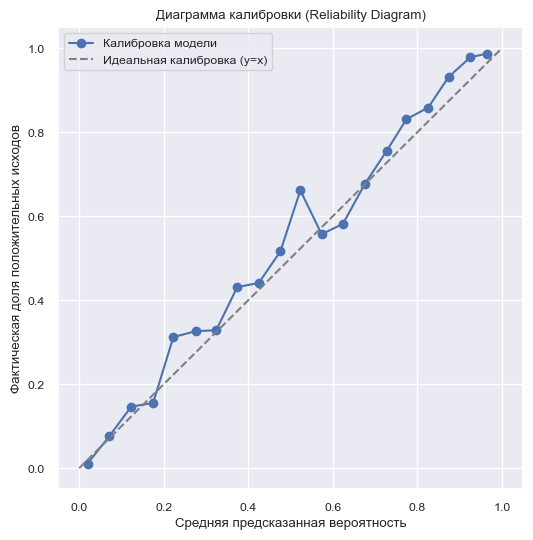

In [37]:
cal_pipeline = clone(selected_pipeline)
cal_pipeline.fit(X_train, y_train)
y_pred_proba_uncal = cal_pipeline.predict_proba(X_cal)[:, 1]
y_prob_true, y_prob_pred = calibration_curve(y_cal, y_pred_proba_uncal, n_bins=20)

# Шаг 3: строим график
def draw_calib_curve(list):
    plt.figure(figsize=(6,6))
    for l in list:
        plt.plot(l[1], l[0], marker='o', label=l[2])

    plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Идеальная калибровка (y=x)')
    plt.xlabel('Средняя предсказанная вероятность')
    plt.ylabel('Фактическая доля положительных исходов')
    plt.title('Диаграмма калибровки (Reliability Diagram)')
    plt.legend()
    plt.grid(True)
    plt.show()

draw_calib_curve([(y_prob_true, y_prob_pred, "Калибровка модели")])
brier_uncal = brier_score_loss(y_cal, y_pred_proba_uncal)
display(HTML(f"<h2>Brier score: </h2>{brier_uncal:.4f}"))

- Откалибруем модель с использованием изотонической калибровки на калибровочной выборке:

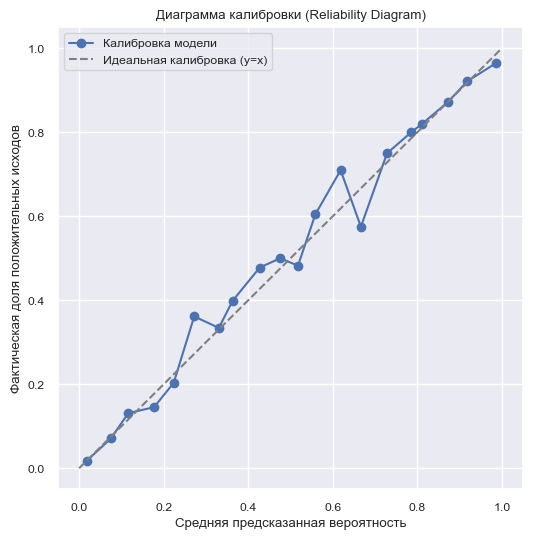

In [38]:
calibrated_pipeline = CalibratedClassifierCV(
    estimator=clone(selected_pipeline),
    method='isotonic',
    cv=cv)
calibrated_pipeline.fit(X_train, y_train)

y_pred_proba_cal = calibrated_pipeline.predict_proba(X_cal)[:, 1]
y_prob_true_cal, y_prob_pred_cal = calibration_curve(y_cal, y_pred_proba_cal, n_bins=20)
draw_calib_curve([(y_prob_true_cal, y_prob_pred_cal, "Калибровка модели")])
brier_cal = brier_score_loss(y_cal, y_pred_proba_cal)
display(HTML(f"<h2>Brier score: </h2>{brier_cal:.4f}"))

- Модель изначально была откалибрована неплохо, калибровка не улучшила показатели модели - метрика Бриера немного увеличилась.

## 7. Поиск порога положительного класса и анализ матрицы ошибок
### 7.1. Поиск порога положительного класса
- Найдём порог, при котором значение Incremental Revenue на калибровочной выборке максимальное:

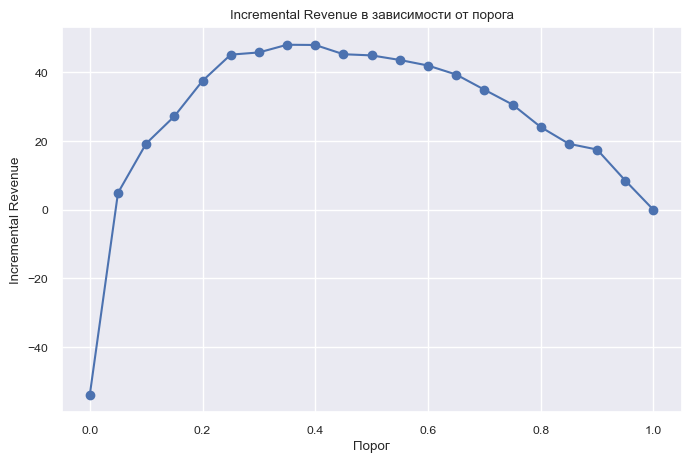

Threshold     0.350000
IR           48.081854
Name: 7, dtype: float64

In [39]:
ths = np.linspace(0, 1.0, 21)
ir_threshold_df = pd.DataFrame({
    'Threshold': [t for t in ths],
    'IR': [incremental_revenue(y_cal, y_pred_proba_cal > t) for t in ths]
})

plt.figure(figsize=(8, 5))
plt.plot(
    ir_threshold_df['Threshold'],
    ir_threshold_df['IR'],
    marker='o'
)

plt.xlabel('Порог')
plt.ylabel('Incremental Revenue')
plt.title('Incremental Revenue в зависимости от порога')
plt.grid(True)

plt.show()
best_thr_ir = ir_threshold_df.sort_values(by='IR', ascending=False).iloc[0]
display(ir_threshold_df.sort_values(by='IR', ascending=False).iloc[0])
best_threshold = best_thr_ir['Threshold']

- Максимальное значение Incremental Revenue достигается при пороге 0.35.

### 7.2. Анализ матрицы ошибок

- Построим матрицу ошибок для калибровочной выборки:

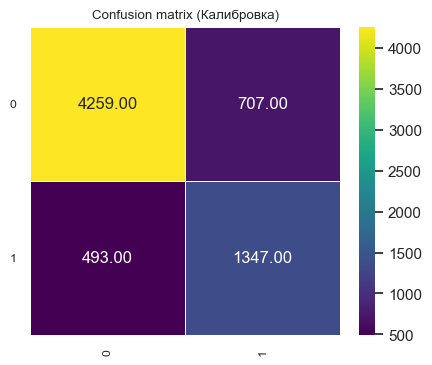

In [40]:
y_pred_cal = y_pred_proba_cal > best_threshold
conf_matrix_cal = confusion_matrix(y_cal, y_pred_cal)
draw_heatmap(conf_matrix_cal,
             "Confusion matrix (Калибровка)",
             figsize=(5, 4),
             font_scale=1)

- Посчитаем предсказание для тестовой выборки и построим соответствующую матрицу ошибок:

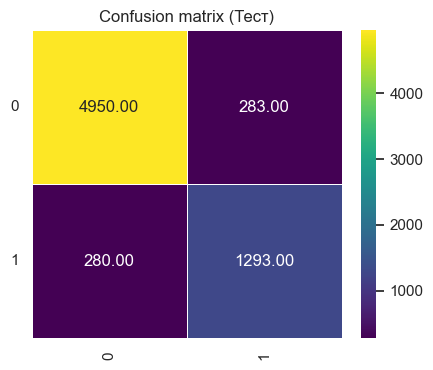

In [41]:
y_pred_proba_test = calibrated_pipeline.predict_proba(X_test)[:, 1]
y_pred_test = y_pred_proba_test > best_threshold
conf_matrix_test = confusion_matrix(y_test, y_pred_test)
draw_heatmap(conf_matrix_test,
             "Confusion matrix (Тест)",
             figsize=(5, 4),
             font_scale=1)

In [42]:
display(pd.DataFrame({"Calibration": calc_metrics(y_cal, y_pred_cal),
                      "Test": calc_metrics(y_test, y_pred_test)}))

,Calibration,Test
accuracy,0.823685,0.917279
precision,0.655794,0.820431
recall,0.732065,0.821996
f1,0.691834,0.821213
IR,48.081854,51.403821
CD,73.206522,82.199619
LD,-27.124446,-24.708580


- Модель показывает лучшие метрики на тестовой выборке, чем на калибровочной, её стабильность удовлетворительна.
- Обучим финальную модель на объединённой обучающей и калибровочной выборках:

,Calibration,Test,Test final
accuracy,0.823685,0.917279,0.923597
precision,0.655794,0.820431,0.824000
recall,0.732065,0.821996,0.851240
f1,0.691834,0.821213,0.837398
IR,48.081854,51.403821,53.446647
CD,73.206522,82.199619,85.123967
LD,-27.124446,-24.708580,-25.587617


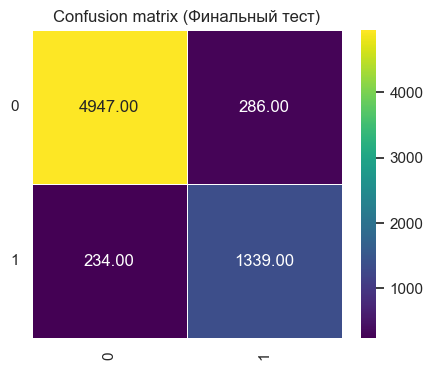

In [43]:
final_pipeline = CalibratedClassifierCV(
    estimator=clone(selected_pipeline),
    method='isotonic',
    cv=cv)
final_pipeline.fit(X_train_cal, y_train_cal)

y_pred_final_test = final_pipeline.predict_proba(X_test)[:, 1] > best_threshold
display(pd.DataFrame({"Calibration": calc_metrics(y_cal, y_pred_cal),
                      "Test": calc_metrics(y_test, y_pred_test),
                      "Test final": calc_metrics(y_test, y_pred_final_test)
                      }))

conf_matrix_final = confusion_matrix(y_test, y_pred_final_test)
draw_heatmap(conf_matrix_final,
             "Confusion matrix (Финальный тест)",
             figsize=(5, 4),
             font_scale=1)

- Матрица ошибок показывает на калибровочной выборке большее количество ложноположительных предсказаний, на тестовой выборке - ошибки сбалансированы.

## 8. Анализ значимости признаков
### 8.1. Оценка значимости при помощи `feature_importances`

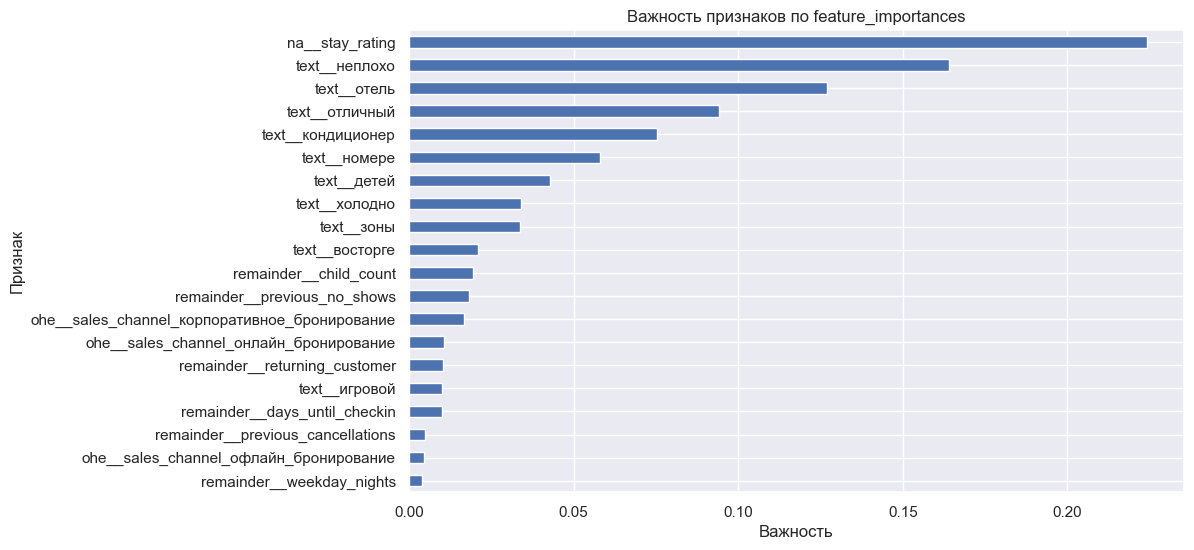

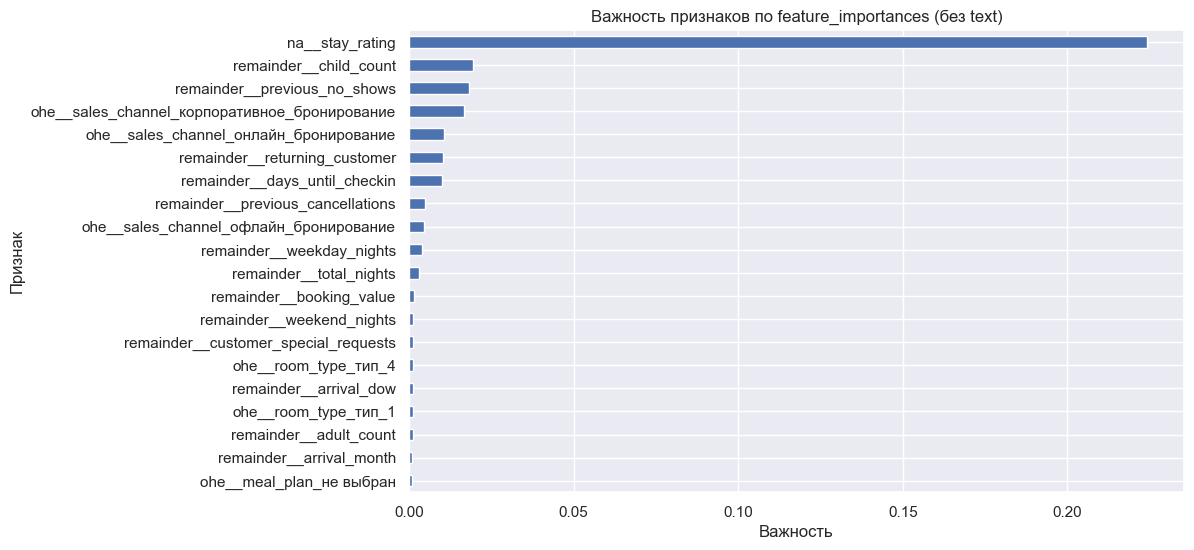

In [44]:
fi_pipeline = clone(selected_pipeline)
fi_pipeline.fit(X_train_cal, y_train_cal)

fi_pp = fi_pipeline.named_steps['pp']
X_pp = fi_pp.transform(X_test)
feat_names = fi_pp.named_steps['ct'].get_feature_names_out()
X_pp_df = pd.DataFrame(X_pp.toarray(), columns=feat_names)

fi_model = fi_pipeline.named_steps['model']
fi = fi_model.feature_importances_

fi_ser = pd.Series(fi, index=feat_names)

draw_barplot(fi_ser.sort_values(ascending=True).tail(20), 
             "Важность признаков по feature_importances", 
             "Признак", 
             "Важность",
             figsize=(10, 6),
             vertical=False)

fi_ser_no_text = fi_ser[~fi_ser.index.str.contains('text', na=False)]

draw_barplot(fi_ser_no_text.sort_values(ascending=True).tail(20), 
             "Важность признаков по feature_importances (без text)", 
             "Признак", 
             "Важность", 
             figsize=(10, 6),
             vertical=False)


- **Поскольку в данных отсутствуют предыдущие отзывы для записей с отменой бронирования, наибольшую важность показывают признаки, имеющие отношение к отзывам (текстовые признаки TF-IDF и рейтинг `stay_rating`): при наличии отзыва модель уверена, что отмены не будет. Эти признаки стоит исключить из рассмотрения (и из обучения), потому что они создают дополнительный шум как на этапе обучения, так и при оценке важности признаков.**

### 8.2. Оценка важности признаков при помощи SHAP

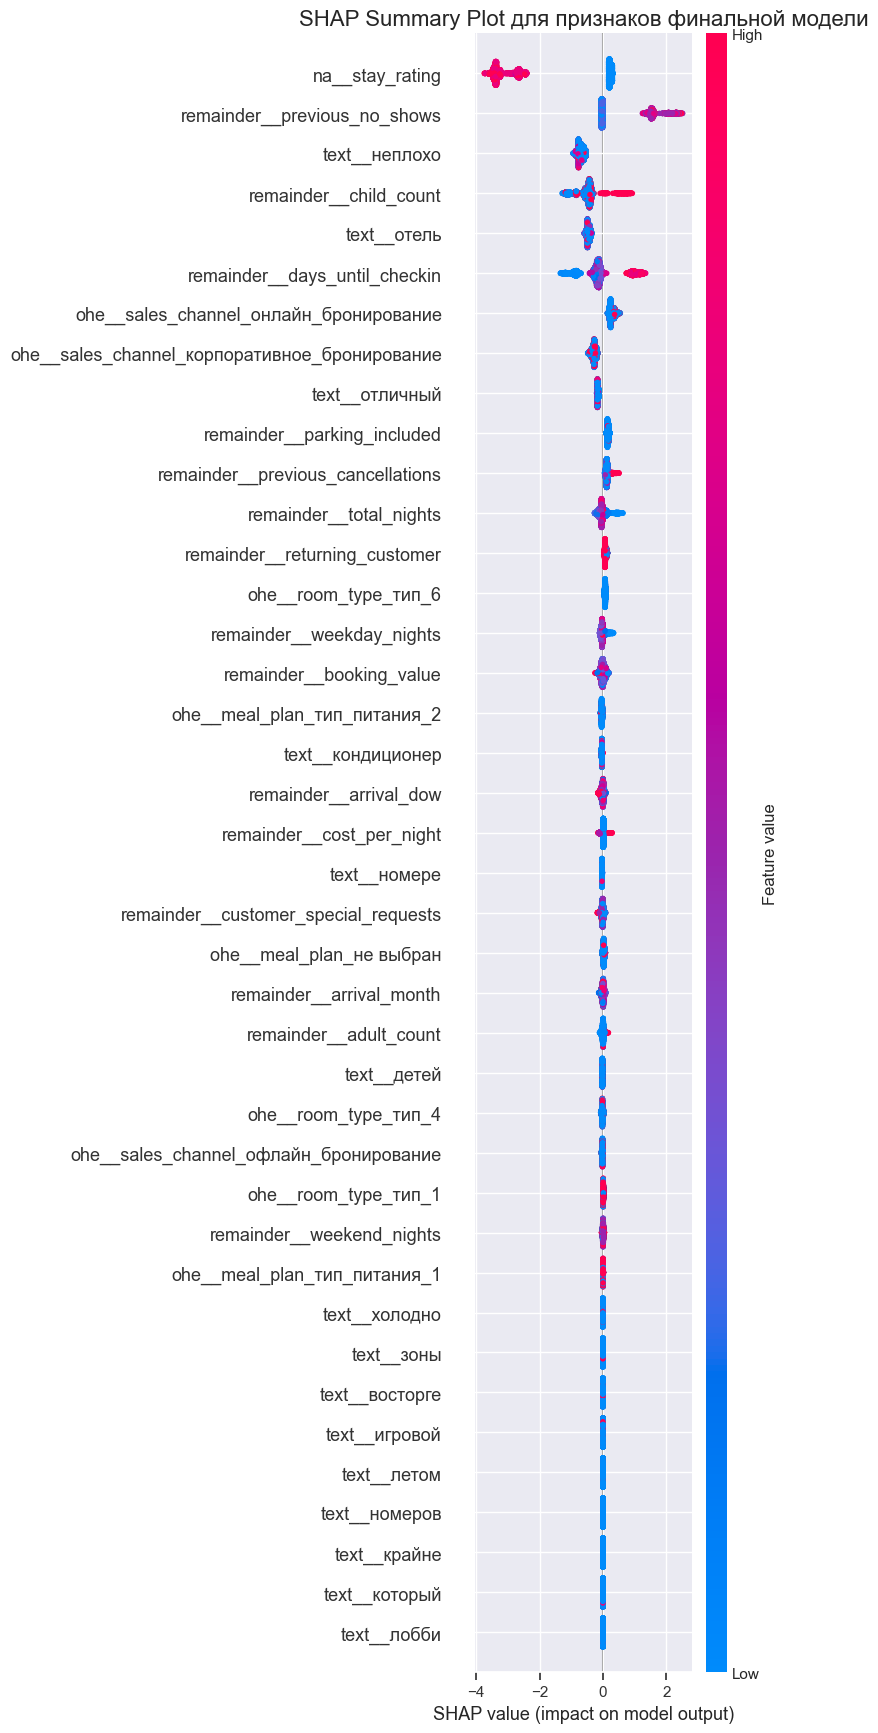

In [45]:
xgb_explainer = shap.TreeExplainer(fi_model)
xgb_shap = xgb_explainer.shap_values(X_pp_df)

plt.figure(figsize=(10, 8))
shap.summary_plot(xgb_shap, X_pp_df, show=False, max_display=40)
plt.title("SHAP Summary Plot для признаков финальной модели", fontsize=16)
plt.tight_layout()
plt.show()

- Как замечено ранее, наиибольшее влияние оказывает наличие предшествующего бронированию рейтинга и комментария. В случае его наличия модель считает, что бронирование не будет отменено. 
- Подтверждается влияние количества детей, дней до заселения, предыдущих неявок и отмен - чем их больше, тем вероятнее отмена.
- Дополнительно к выявленным ранее зависимостям диаграмма демонстрирует слабую зависимость вероятности отмены от количества взрослых гостей и цены за ночь - при их увеличении вероятность отмены растёт.

### 8.3. Оценка важности признаков при помощи Permutation Importance

In [46]:
pi = permutation_importance(
    fi_model, X_pp_df, y_test, 
    n_repeats=10, random_state=RANDOM_SEED, 
    scoring=ir_scorer
)

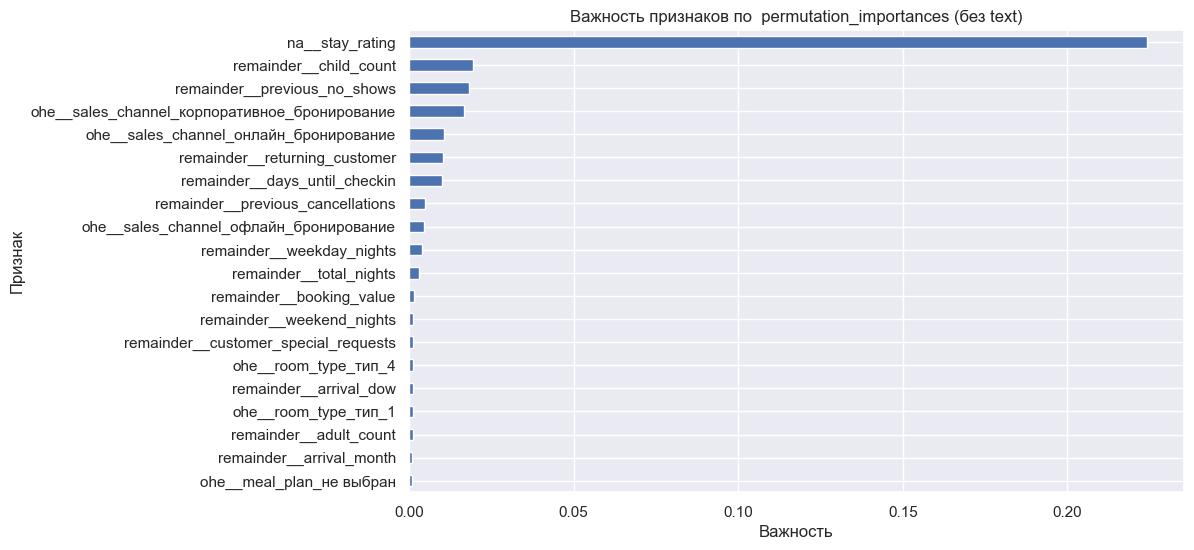

In [47]:
pi_ser = pd.Series(fi, index=feat_names)
pi_ser_no_text = pi_ser[~pi_ser.index.str.contains('text', na=False)]

draw_barplot(pi_ser_no_text.sort_values(ascending=True).tail(20), 
             "Важность признаков по  permutation_importances (без text)", 
             "Признак", 
             "Важность", 
             figsize=(10, 6),
             vertical=False)

### 8.4. Выводы
- Самым важным признаком на предоставленном наборе данных оказывается наличие предыдущего рейтинга и комментария - из-за особенностей датасета предыдущий рейтинг и комментарий есть только у подтвержденных бронирований, поэтому модель уверена, что если комментарий присутствует, то отмены не будет. В реальной жизни на эту закономерность полагаться не следует, поэтому признаки, относящиеся к рейтингу и комментариям (TF-IDF) следует исключить из анализа.
- Чем больше детей, тем больше вероятность отмены брони. Возможно, отели не располагают необходимой инфраструктурой для семейного отдыха с детьми, и клиенты, находя более подходящее предложение, отменяют бронь. В этом случае следует уделять больше внимания организации отдыха клиентов с детьми: предусмотреть анимацию, наличие игровых комнат и прочей детской и семейной инфраструктуры.
- Корпоративное бронирование более надёжно, чем индивидуальное бронирование через интернет: онлайн-брони отменяются чаще. Также следует обращать внимание на предыдущее поведение клиента: случавшиеся ранее отмены и неявки повышают вероятность отмены брони. Для таких проблемных клиентов, регистрирующихся онлайн, стоит предусмотреть внесение предоплаты или взимание платы за отмену брони.
- Есть чёткая зависимость между вероятностью отмены брони и интервалом времени от бронирования до заезда. Как было замечено на этапе исследовательского анализа, при увеличении этого интервала более 170 дней вероятность отмены вырастает более 50%. Для таких бронирований можно применять овербукинг.
- Также овербукинг можно применять для номеров, бронируемых на одну ночь, особенно в будние дни. Вероятность отмены таких бронирований также высока, а накладные расходы при переселении в другой номер незначительны.

## 9. Расчёт экономической эффективности модели
- Посчитаем показатели до и после внедрения модели на тестовой выборке:

In [52]:
eco_metrics_ser = pd.Series({
    'Rev. Before': revenue_before(y_test),
    'Rev. After': revenue_after(y_test, y_pred_final_test),
    'Incremental Revenue': incremental_revenue(y_test, y_pred_final_test),
    'Canc. Ratio Before': cancellation_ratio_before(y_test),
    'Canc. Ratio After': cancellation_ratio_after(y_test, y_pred_final_test),
    'Canc. Ratio Dynamic': cancellation_dynamic(y_test, y_pred_final_test),
    'Load Before': load_before(y_test),
    'Load After': load_after(y_test, y_pred_final_test),
    'Load Dynamic': load_dynamic(y_test, y_pred_final_test)
})

display(eco_metrics_ser)

Rev. Before           236070000.0000
Rev. After            362241500.0000
Incremental Revenue          53.4466
Canc. Ratio Before           23.1120
Canc. Ratio After             3.4381
Canc. Ratio Dynamic          85.1240
Load Before                  76.8880
Load After                   96.5619
Load Dynamic                -25.5876
dtype: float64

### Выводы
- Выручка, рассчитанная по формуле Incremental Revenue, в результате внедрения модели увеличилась на 53.4%
- Доля отмен снизилась с 23.1% до 3.4% (на 85%)
- Загрузка отеля выросла с 76.7% до 96.6% (на 25.6%)
- Целевые показатели достигнуты с большим запасом.

## 10. Выводы по проекту
- Для анализа был предоставлен датасет из двух таблиц. Пропусков в датасетах нет, выбросы относятся к корпоративному сегменут и аномалиями не являются.
- Данные о бронировании представлены за период с 01.01.2017 по 22.10.2025. Пик приходится на 2020 год, начиная с 2021 года количество записей о бронировании начинает резко убывать.
- Классы целевой переменной несбалансированы, положительный класс в 2.5 раза меньше отрицательного. Оверсэмплинг/ андерсэмплинг не требуется.
- По результатам исследовательского анализа данных среди признаков, указывающих на высокую вероятность отмены брони, можно отметить наличие двух детей, время до заселения более 150 дней, наличие предыдущих отмен, бронирование на одну ночь в будние дни, онлайн-бронирование.
- Таблицы были объединены в единый датасет, для модели `CatBoostClassifier` текстовые и категориальные признаки не предобрабатывались, для других моделей (`RandomForestClassifier`, `XGBClassifier`, `LGBMClassifier`) текстовый комментарий был закодирован с использованием TF-IDF, категориальные признаки - с использованием One Hot Encoding.
- **Было установлено, что предыдущий рейтинг и текстовый комментарий имеются только у подтвержденных бронирований, поэтому правильно было бы обучать модели, исключив эти признаки, т.е., фактически, на признаках только из одной таблицы. Однако ввиду учебной цели задания предобработка текстового комментария и полученные из него признаки были оставлены.**
- Были обучены 4 модели (`RandomForestClassifier`, `RandomForestClassifier`, `XGBClassifier`, `LGBMClassifier`) с параметрами по умолчанию. Лучшие результаты показали модели `CatBoostClassifier` и `XGBClassifier`.
- Для всех 4 моделей был выполнен подбор гиперпараметров. Лучшие результаты показала модель `XGBClassifier`, которая и была выбрана для дальнейшей работы.
- Выбранная модель была откалибрована с использованием изотонической калбировки на отдельной калибровочной выборке. Качество калибровки модели улучшилось незначительно, так как модель изначально была откалибрована достаточно хорошо.
- Модель была обучена на объединённой обучающей и калибровочной выборке и протестирована на отложенной тестовой выборке.
- Все бизнес-метрики достигли целевых значений с запасом, цель проекта достигнута:
    - Выручка, рассчитанная по формуле Incremental Revenue, в результате внедрения модели увеличилась на 53.4%
    - Доля отмен снизилась с 23.1% до 3.4% (на 85%)
    - Загрузка отеля выросла с 76.7% до 96.6% (на 25.6%)
- Был выполнен анализ влияния признаков на предсказание и сформулированы рекомендации для бизнеса.
    - Самым важным признаком на предоставленном наборе данных оказывается наличие предыдущего рейтинга и комментария - из-за особенностей датасета предыдущий рейтинг и комментарий есть только у подтвержденных бронирований, поэтому модель уверена, что если комментарий присутствует, то отмены не будет. В реальной жизни на эту закономерность полагаться не следует, поэтому признаки, относящиеся к рейтингу и комментариям (TF-IDF) следует исключить из анализа.
    - Чем больше детей, тем больше вероятность отмены брони. Возможно, отели не располагают необходимой инфраструктурой для семейного отдыха с детьми, и клиенты, находя более подходящее предложение, отменяют бронь. В этом случае следует уделять больше внимания организации отдыха клиентов с детьми: предусмотреть анимацию, наличие игровых комнат и прочей детской и семейной инфраструктуры.
    - Корпоративное бронирование более надёжно, чем индивидуальное бронирование через интернет: онлайн-брони отменяются чаще. Также следует обращать внимание на предыдущее поведение клиента: случавшиеся ранее отмены и неявки повышают вероятность отмены брони. Для таких проблемных клиентов, регистрирующихся онлайн, стоит предусмотреть внесение предоплаты или взимание платы за отмену брони.
    - Есть чёткая зависимость между вероятностью отмены брони и интервалом времени от бронирования до заезда. Как было замечено на этапе исследовательского анализа, при увеличении этого интервала более 170 дней вероятность отмены вырастает более 50%. Для таких бронирований можно применять овербукинг.
    - Также овербукинг можно применять для номеров, бронируемых на одну ночь, особенно в будние дни. Вероятность отмены таких бронирований также высока, а накладные расходы при переселении в другой номер незначительны.
